<a href="https://colab.research.google.com/github/ch11nn/SC3021/blob/main/SC3021_Project_Group_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
# Import necessary libraries for data preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
from IPython.display import Image
import re
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.formula.api as smf

In [94]:
# Set data path: use GitHub raw URLs in Colab, local paths otherwise
import os
if 'COLAB_RELEASE_TAG' in os.environ:
    DATA_PREFIX = 'https://raw.githubusercontent.com/ch11nn/SC3021/refs/heads/main/data/'
    print('Running in Google Colab — loading data from GitHub')
else:
    DATA_PREFIX = 'data/'
    print(f'Running locally — loading data from {{DATA_PREFIX}}')

Running in Google Colab — loading data from GitHub


In [95]:
# Validate that required data files are accessible
required_files = [
    '(DS1)_RainfallMonthlyTotal.csv',
    '(DS3)_RoadTrafficAccidentCasualtiesMonthly.csv',
    '(DS4)_AverageDailyTrafficVolumeEnteringtheCity.csv',
    '(DS5)_MotorVehiclePopulationByTypeOfVehicleEndOfPeriodMonthly.csv',
    'sc3021_group9_clean_data.csv'
]

if not DATA_PREFIX.startswith('http'):
    for f in required_files:
        path = os.path.join(DATA_PREFIX, f)
        status = 'OK' if os.path.exists(path) else 'MISSING'
        print(f'  {status}: {path}')
else:
    print('Running in Colab — data files will be fetched from GitHub.')

Running in Colab — data files will be fetched from GitHub.


# **Does rainfall affect the frequency of traffic accident in Singapore?**

---

**Team Member:**  Chin Jiaqi, Gao WenBo

**Lab Group:** ECDS1, Group 09

---


## Hypothesis/analysis goal (Ask)

Rainfall can influence driving conditions in Singapore by reducing road friction, impairing visibility, and increasing driver reaction times. These effects may raise both the frequency and severity of traffic accidents. The goal of this project is to investigate whether variations in rainfall intensity and duration in Singapore are associated with changes in traffic accident outcomes.

This study will explore the relationship between rainfall and traffic accidents using historical accident and meteorological data from Singapore. The aim is to understand how rainfall affects road safety across different locations and time periods within the country. The findings could provide insights to improve traffic management and road safety planning during rainy conditions.

# Part 1: Data Engineering / Preparation

## Data Source Identification

### Requirement Analysis

To solve our derived problem statement, we would need data on the following:

1. **Historical data on rainfall patterns across different periods of the year** – Provides monthly precipitation measurements. This dataset serves as the primary explanatory variable, allowing us to quantify rainfall intensity and patterns over time.
2. **Traffic accident record data** – Contains monthly accident counts. This dataset forms the outcome variable of interest, enabling analysis of the frequency and timing of traffic accidents.
3. **Traffic volume data** – Provides information on traffic flow or vehicle counts. This data is crucial to account for exposure (i.e., the number of vehicles on the road) and helps improve the accuracy of the relationship between rainfall and accident frequency.

Datasets should not be too outdated to ensure that the analysis reflects current conditions and remains relevant for decision making.


### List of Considered Sources

The datasets selected as the final sources are indicated with an *.

* **Rainfall Pattern**
  * [*Rainfall - Monthly Total Singapore from Jan 1982 to Feb 2026 (DS1)](https://data.gov.sg/datasets/d_b16d06b83473fdfcc92ed9d37b66ba58/view)
  * [Rainfall across Singapore (station-level API) from Dec 2016 to Feb 2026 (DS2)](https://data.gov.sg/datasets/d_6580738cdd7db79374ed3152159fbd69/view)

* **Traffic Accident**
  * [*Singapore Road Traffic Accident Casualties, Monthly from Jan 2009 to Nov 2025 (DS3)](https://data.gov.sg/datasets/d_5dec466b08a55497218daf8bafbfe96c/view)

* **Traffic Volume**
  * [*Average Daily Traffic Volume Entering the City from Jan 2004 to Jan 2023 (DS4)](https://data.gov.sg/datasets/d_3136f317a1f282a33fe7a2f6a907c047/view)
  * [Motor Vehicle Population by Type of Vehicle, Monthly from Jan 1962 to Jan 2026 (DS5)](https://data.gov.sg/datasets/d_206838bdc92c07ab495af49475563da5/view)

## Data Exploration
In the following, we explored and justified for the selection of each dataset.

### DS1: Rainfall Monthly Total (Jan 1982 – Jan 2026)

**Description:** This dataset provides total monthly rainfall in millimetres recorded at Changi, Singapore's primary reference meteorological station. It was extracted from data.gov.sg. It contains two columns: month (YYYY-MM) and total_rainfall (mm).

In [96]:
ds1_raw = pd.read_csv(DATA_PREFIX + '(DS1)_RainfallMonthlyTotal.csv')
ds1_raw.head()

,month,total_rainfall
0,1982-01,107.1
1,1982-02,27.8
2,1982-03,160.8
3,1982-04,157.0
4,1982-05,102.2


In [97]:
ds1_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           530 non-null    object 
 1   total_rainfall  530 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.4+ KB


In [98]:
ds1_raw.isnull().sum()

,0
month,0
total_rainfall,0


From the above, we can see that there are no missing values in DS1. This simplifies the data cleaning process as no imputation is required.

**Exploring the distribution of monthly rainfall across the full period**

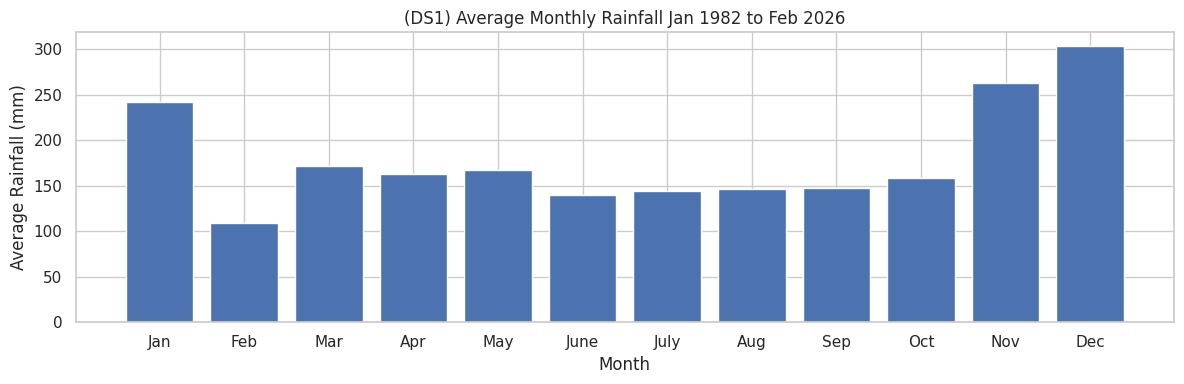

In [99]:
ds1_raw['month'] = pd.to_datetime(ds1_raw['month'])

ds1_explore = ds1_raw.copy()
ds1_explore['month_of_year'] = ds1_explore['month'].dt.month
monthly_avg = ds1_explore.groupby('month_of_year')['total_rainfall'].mean()

months_name = ['Jan','Feb','Mar','Apr','May','June',"July",'Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(12, 4))
plt.bar(months_name,monthly_avg.values)
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.title('(DS1) Average Monthly Rainfall Jan 1982 to Feb 2026')
plt.tight_layout()
plt.show()

From the above, we can see that rainfall follows a seasonal pattern consistent with Singapore's monsoon calendar.
1. Northeast Monsoon season: **November-January**
2. Southwest Monsoon: **June–September**

The Northeast Monsoon produces significantly higher rainfall than the Southwest Monsoon with average rainfall ≥ 250mm. This is because Sumatra acts as a geographical barrier that reduces moisture during the southwest winds, while the Northeast Monsoon brings unobstructed winds across the South China Sea.

On the other hand, February records the lowest average (around 110mm).
This seasonal variation — where some months receive nearly three times more rainfall than others — provides the contrast needed to test whether higher rainfall months are associated with more traffic accidents.

**Rainfall Distribution**

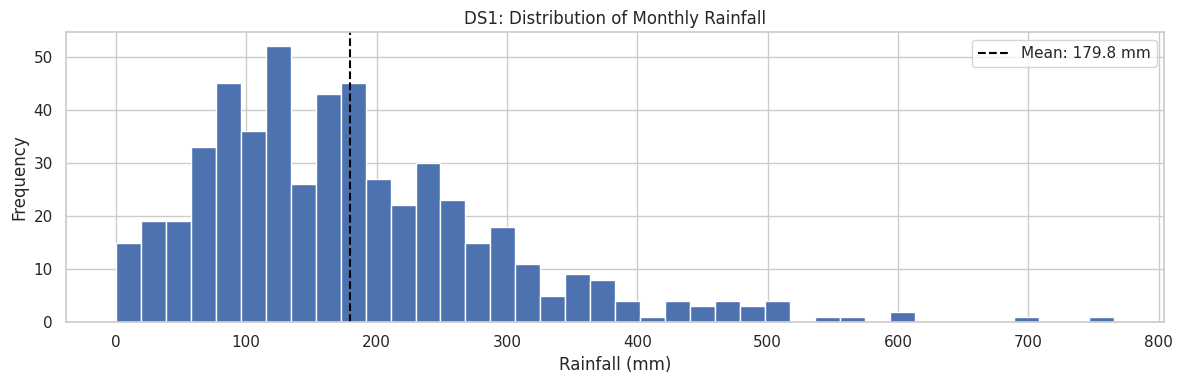

In [100]:
plt.figure(figsize=(12, 4))
plt.hist(ds1_raw['total_rainfall'], bins=40, edgecolor='white')
plt.axvline(ds1_raw['total_rainfall'].mean(), color='black', linestyle='--', label=f"Mean: {ds1_raw['total_rainfall'].mean():.1f} mm")
plt.title('DS1: Distribution of Monthly Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

From the above, the distribution is right-skewed, meaning most months have moderate rainfall but a small number of months record extreme values (above 500 mm). This is consistent with Singapore's occasional intense monsoon events.

**Data Quality Considerations**

***Completeness:*** There are no missing values across 529 months, providing a fully populated time series that requires no imputation.

***Reputation:*** The dataset is published by the Meteorological Service Singapore (MSS) via data.gov.sg and is the official reference source for Singapore-wide monthly rainfall statistics.

***Temporal Resolution:*** The data is at monthly granularity, which is consistent with the monthly accident and traffic datasets we are using.

**Conclusion for DS1**

This dataset is selected as the primary rainfall variable. It is complete, reliable, and directly aligned with the monthly granularity of our accident outcome data. While daily station-level data exists at weather.gov.sg, daily rainfall would need to be aggregated to monthly regardless since our accident data (DS3) is only available monthly — making DS1 the more practical choice as it already provides the same information in a ready-to-use format.

### DS2: Rainfall across Singapore

**Description**: This dataset is a real-time API endpoint from data.gov.sg that returns 5 minute rainfall readings from individual stations across Singapore.


**Profiling**: The API returns readings per timestamp across all active stations. Retrieving a full time series for our analysis window would require approximately 105,000 individual API calls (one per 5-minute interval). Station availability also varies — not all stations have consistent records across the full period.


**Data Quality Considerations**

***Completeness***: Station coverage is inconsistent over time, introducing potential gaps in a long time-series.

***Temporal resolution mismatch***: The 5-minute granularity is far finer than needed. Since DS3 is only available monthly, any sub-monthly rainfall data would need to be aggregated to monthly anyway — producing the same output as DS1 at significantly more collection effort.



**Conclusion for DS2**

Not selected. After aggregation, DS2 yields the same monthly city-level totals as DS1. The added complexity of API collection is not justified for our monthly analysis. But DS2 remains a useful candidate for future event-level or sub-regional work.

### DS3: Road Traffic Accident Casualties, Monthly (Jan 2009 – Dec 2025)

**Description:** This dataset provides monthly road traffic accident casualties in Singapore, broken down by road user type (e.g. pedestrians, motorcyclists, car occupants). It was extracted from data.gov.sg. The raw format is wide — rows represent casualty categories and columns represent months.

In [101]:
ds3_raw = pd.read_csv(DATA_PREFIX + '(DS3)_RoadTrafficAccidentCasualtiesMonthly.csv')
ds3_raw.head()

,DataSeries,2025Dec,2025Nov,2025Oct,2025Sep,2025Aug,2025Jul,2025Jun,2025May,2025Apr,...,2009Oct,2009Sep,2009Aug,2009Jul,2009Jun,2009May,2009Apr,2009Mar,2009Feb,2009Jan
0,Total Casualties Fatalities,11,13,13,12,10,11,17,18,11,...,13,18,14,16,10,22,14,11,12,13
1,Pedestrians,5,4,1,3,2,2,4,3,3,...,3,4,3,4,5,2,3,3,3,4
2,Personal Mobility Device Users,0,0,0,1,0,0,0,0,0,...,na,na,na,na,na,na,na,na,na,na
3,Cyclists & Pillions,1,4,0,1,1,0,2,1,0,...,1,3,1,2,1,2,3,1,0,0
4,Motor Cyclists & Pillion Riders,4,5,10,5,4,8,10,11,7,...,7,9,10,8,4,8,4,6,8,7


In [102]:
print(f'Raw Dataset Shape: {ds3_raw.shape}')
print(f'Number of casualty categories (row): {len(ds3_raw)}')
print(f'Number of month covered (column): {ds3_raw.shape[1] - 1}')

Raw Dataset Shape: (30, 205)
Number of casualty categories (row): 30
Number of month covered (column): 204


We will need to combine DS1, DS3 and DS4 together but DS3 is currently in wide format. We won't be able to join DS3 with DS1 and DS4 which have one row per month. In order to merge all 3 datasets together, we will need to reshape DS3 so that each month becomes its own row instead (ie long format). This long format allows us to align rainfall and casualty values for the same month, which is necesssary for our analysis later on. Without this reshaping, the merge and subsequent analysis cannot be performed.

**Reshaping DS3 to tidy format for exploration**

In [103]:
# temporary reshape for exploration purposes only
# full preparation is done in the Data Preparation section below

#define helper function to parse month strings like '2025Dec'
def parse_month_ds3(s):
    m = re.match(r'(\d{4})([A-Za-z]{3})', str(s))
    if m:
        try:
            return pd.to_datetime(m.group(1) + '-' + m.group(2), format='%Y-%b')
        except:
            return pd.NaT
    return pd.NaT

#melt to long format
ds3_long = ds3_raw.melt(id_vars='DataSeries', var_name='month_str', value_name='value') #Fatalities and Injured share the same casualty categories so they get merged into one column
ds3_long['month'] = ds3_long['month_str'].apply(parse_month_ds3)
ds3_long = ds3_long.dropna(subset=['month'])
ds3_long['value'] = pd.to_numeric(ds3_long['value'], errors='coerce')

#pivot to tidy wide form with one row per month
ds3 = ds3_long.pivot_table(index='month', columns='DataSeries', values='value', aggfunc='first')
ds3.columns = [c.strip() for c in ds3.columns]
ds3 = ds3.sort_index()
ds3.index = pd.to_datetime(ds3.index)

ds3 = ds3.astype("Int64")

print(f'Shape after reshaping: {ds3.shape}')
print(f'Number of month covered (row): {len(ds3)}')
print(f'Number of casualty categories (column): {ds3.shape[1]}')
print(f'Date range: {ds3.index.min().strftime("%Y-%m")} to {ds3.index.max().strftime("%Y-%m")}')

Shape after reshaping: (204, 16)
Number of month covered (row): 204
Number of casualty categories (column): 16
Date range: 2009-01 to 2025-12


From the above, we can see that after reshaping, the dataset has 204 rows (one per month) and 16 columns (one per casualty category). The number of columns reduced from 30 to 16 because the original dataset had two blocks of the same vehicle-type categories:

1. one block under “Total Casualties Fatalities”
2. another block under “Total Casualties Injured”

During the pivot, these duplicate category names were merged into single columns.

<img src="https://drive.google.com/uc?export=view&id=1-1jXRct0-s02wkQv-skuxflC_oTWcCCw" width="200">

The reshaped dataset ends up with 16 columns instead of 15 because 'Tipper Trucks' appears exclusively under 'Total Casualties Fatalities' but not under 'Total Casualties Injured', giving it its own separate column.

In [104]:
print("AFTER reshaping (LONG): one row per MONTH")
print(f"Shape: {ds3.shape}")
ds3.reset_index().head()

AFTER reshaping (LONG): one row per MONTH
Shape: (204, 16)


,month,Goods Vans,Lorries,Pick-Ups,Tipper Trucks,Trailers,Buses,Cyclists & Pillions,Goods Vans & Pick-Ups,"Lorries, Tipper Trucks & Trailers",Motor Cars And Station Wagons,Motor Cyclists & Pillion Riders,Others,Pedestrians,Personal Mobility Device Users,Total Casualties Fatalities,Total Casualties Injured
0,2009-01-01,0,1,0,1,0,0,0,0,2,0,7,0,4,<NA>,13,898
1,2009-02-01,0,0,0,0,0,0,0,0,0,1,8,0,3,<NA>,12,853
2,2009-03-01,0,0,0,0,0,1,1,0,0,0,6,0,3,<NA>,11,918
3,2009-04-01,2,0,0,0,0,1,3,2,0,1,4,0,3,<NA>,14,897
4,2009-05-01,2,4,0,0,0,0,2,2,4,4,8,0,2,<NA>,22,927


In [105]:
ds3.isnull().sum().sort_values(ascending=False)

,0
Personal Mobility Device Users,96
Goods Vans,0
Pick-Ups,0
Lorries,0
Trailers,0
Buses,0
Cyclists & Pillions,0
Tipper Trucks,0
Goods Vans & Pick-Ups,0
"Lorries, Tipper Trucks & Trailers",0


From the above, we can see that only the 'Personal Mobility Device Users' column has missing values (96 NaN values). This is because PMD-related data was only tracked from 2017 onwards, so earlier months contain 'na' strings which were coerced to NaN. Importantly, the 'Total Casualties Fatalities' and 'Total Casualties Injured' columns — which are our primary outcome variables — have no missing values.


**Exploring Total Fatalities and Injuries over time**

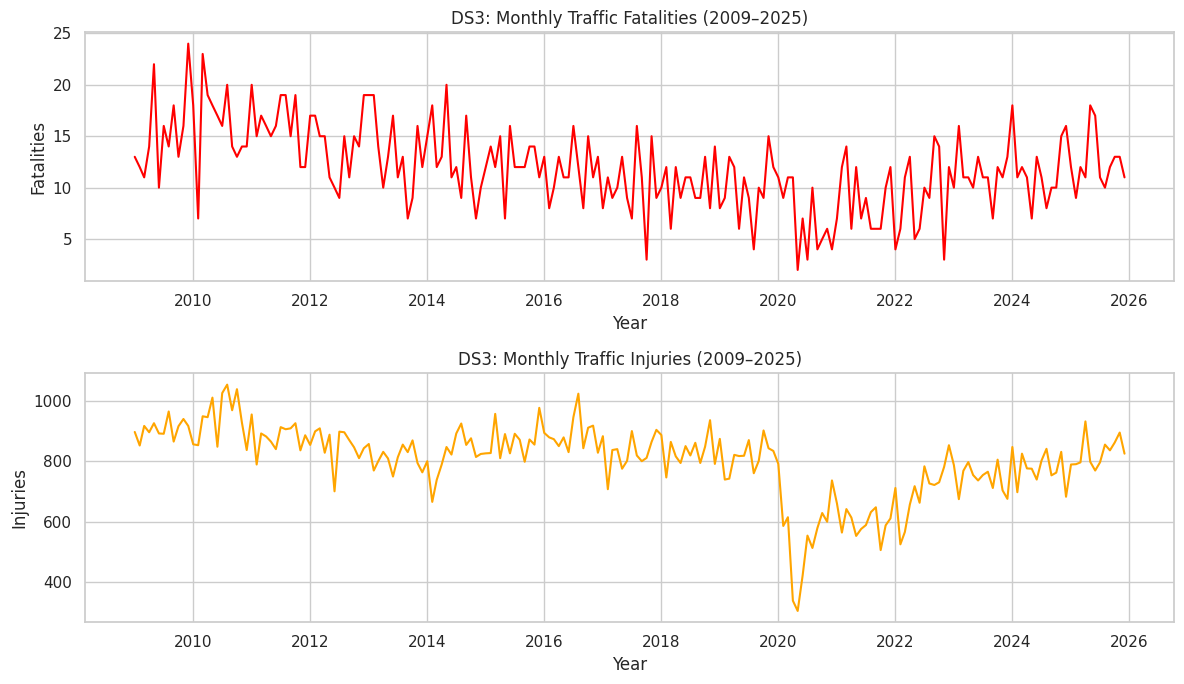

In [106]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(ds3.index, ds3['Total Casualties Fatalities'], color='red')
axes[0].set_title('DS3: Monthly Traffic Fatalities (2009–2025)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Fatalities')

axes[1].plot(ds3.index, ds3['Total Casualties Injured'], color='orange')
axes[1].set_title('DS3: Monthly Traffic Injuries (2009–2025)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Injuries')

plt.tight_layout()
plt.show()

From the above, we can observe that monthly fatalities show a gradual decline from around 20 in 2009 to around 10 in recent years, which may reflect improved road safety measures over time. Monthly injuries, however, remained relatively stable between 800–1000 from 2009 to 2019 before dropping sharply around 2020–2021, likely attributable to reduced traffic volumes during the COVID-19 pandemic, followed by a recovery towards pre-pandemic levels. This COVID-19 structural break is an important consideration and will be accounted for in the analysis.

**Descriptive Statistics for Key Outcome Variables**

In [107]:
ds3[['Total Casualties Fatalities', 'Total Casualties Injured']].describe().round(2)

,Total Casualties Fatalities,Total Casualties Injured
count,204.0,204.0
mean,11.93,804.52
std,4.01,118.65
min,2.0,304.0
25%,9.75,759.5
50%,12.0,827.0
75%,14.25,880.0
max,24.0,1055.0


**Data Quality Considerations**

***Completeness***: Upon checking for missing values, we found that the 'Personal Mobility Device Users' breakdown column contains 96 missing values. This is because PMDs were only introduced as a tracked category from 2017 onwards. Prior to that, PMD-related casualties were either non-existent or grouped under 'Others'. However, this does not pose a problem for our analysis as we are only using 'Total Casualties Fatalities' and 'Total Casualties Injured' as our outcome variables, both of which are complete across all 204 months with no missing values. The PMD breakdown column will be excluded from further analysis.

***Format***: The raw wide format requires reshaping to long format before analysis, which we carry out in the data preparation section.

***Reputation***: The dataset is published by the Singapore Police Force via data.gov.sg and is the official source for Singapore road traffic statistics.

**Conclusion for DS3: Road Traffic Accident Casualties**

This dataset is selected as the primary outcome variable. It is the only publicly available monthly accident dataset for Singapore and covers our full analysis window (2009–2025) with no missing values in the total casualty columns. We note that DS3 records casualties (people harmed) rather than incident counts. This is clearly acknowledged as an assumption — we treat casualty count as a proxy for accident frequency, which is consistent with prior Singapore traffic safety studies.

### DS4: Average Daily Traffic Volume Entering the City (2004 – 2023)

**Description:** This dataset provides the average daily number of vehicles entering the city (central area) per year, published by the Land Transport Authority (LTA) via data.gov.sg. It contains two columns: year and average daily traffic volume (vehicles/day).



In [108]:
ds4_raw = pd.read_csv(DATA_PREFIX + '(DS4)_AverageDailyTrafficVolumeEnteringtheCity.csv')
ds4_raw

,year,ave_daily_traffic_volume_entering_city
0,2004,246000
1,2005,244000
2,2006,270400
3,2007,278300
4,2008,278100
5,2009,278400
6,2010,293300
7,2011,300000
8,2012,292000
9,2013,289000


In [109]:
ds4_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   year                                    20 non-null     int64
 1   ave_daily_traffic_volume_entering_city  20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes


In [110]:
ds4_raw.isnull().sum()

,0
year,0
ave_daily_traffic_volume_entering_city,0


From the above, we can see that DS4 is a compact dataset with no missing values. It covers 20 years (2004–2023) at annual granularity.

**Exploring Traffic Volume over the Years**

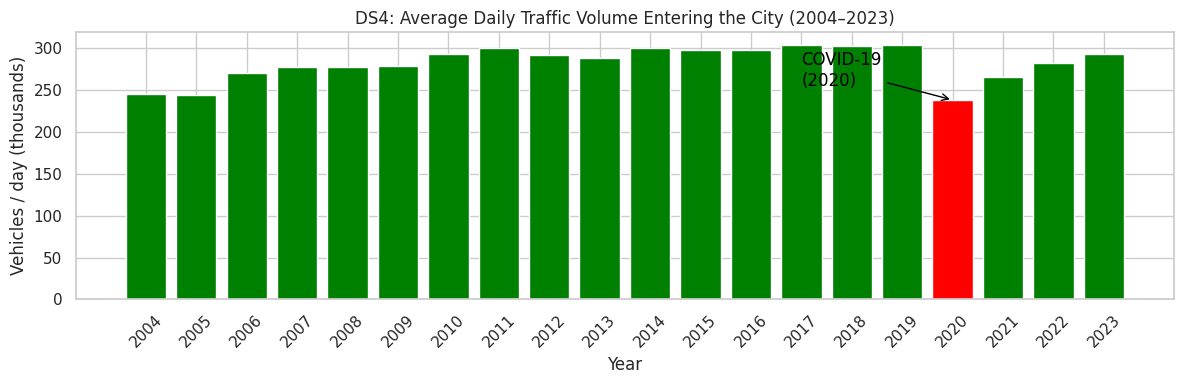

In [111]:
ds4 = ds4_raw.rename(columns={'ave_daily_traffic_volume_entering_city': 'traffic_volume'})
ds4['year'] = ds4['year'].astype(int)

bar_colors = ['red' if y == 2020 else 'green' for y in ds4['year']]

plt.figure(figsize=(12, 4))
plt.bar(ds4['year'], ds4['traffic_volume'] / 1000, color=bar_colors, edgecolor='white')
plt.title('DS4: Average Daily Traffic Volume Entering the City (2004–2023)')
plt.xlabel('Year')
plt.ylabel('Vehicles / day (thousands)')
plt.xticks(ds4['year'], rotation=45)

# annotate the COVID-19 dip
idx_min = ds4['traffic_volume'].idxmin()
plt.annotate('COVID-19\n(2020)', xy=(2020, ds4.loc[idx_min, 'traffic_volume']/1000),
             xytext=(2017, 255), color='black',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

From the above, we can see that traffic volume was relatively stable between 290,000–304,000 vehicles/day from 2006 to 2019. There is a sharp drop in 2020 (238,300 vehicles/day) due to COVID-19 movement restrictions, followed by a recovery trend in 2021–2023. This structural break is real and not a data error, and will be flagged when interpreting results.

**Descriptive Statistics for Traffic Volume**

In [112]:
ds4['traffic_volume'].describe().round(0)

,traffic_volume
count,20.0
mean,282800.0
std,20581.0
min,238300.0
25%,276175.0
50%,290500.0
75%,298800.0
max,304000.0


**Data Quality Considerations**

***Completeness***: No missing values across all 20 years.

***Temporal Resolution***: DS4 is annual, which is a key limitation. It cannot be directly joined to the monthly accident and rainfall data. We address this by expanding it to a monthly series in the data preparation stage, repeating each year's value across all 12 months of that year. This is admittedly a rough approximation. However, given that no monthly traffic flow data is publicly available in Singapore, this is the best we can do. We have explicitly acknowledged this as an assumption of our analysis.

***Coverage Gap***: DS4 ends at 2023. Months in 2024–2025 will need to be forward-filled using the 2023 value as a proxy, which is clearly stated as an assumption.

***Reputation***: The dataset is published by LTA via data.gov.sg.

**Conclusion for DS4: Average Daily Traffic Volume**

This dataset is selected as the traffic exposure control variable. While its annual granularity is a limitation, it is the only available flow-based traffic measure (vehicles actually on the road) for our analysis period. Other candidates — such as Motor Vehicle Population (stock measure of registered vehicles) and Public Transport Ridership (measures bus/MRT passengers, not drivers) — were considered but rejected as they do not reflect actual private vehicle traffic on roads.

### DS5: Motor Vehicle Population by Type of Vehicle, Monthly (Jan 1962 – Jan 2026)

In [113]:
ds5_raw = pd.read_csv(DATA_PREFIX + '(DS5)_MotorVehiclePopulationByTypeOfVehicleEndOfPeriodMonthly.csv')
ds5_raw.head()

,DataSeries,2026Jan,2025Dec,2025Nov,2025Oct,2025Sep,2025Aug,2025Jul,2025Jun,2025May,...,1962Oct,1962Sep,1962Aug,1962Jul,1962Jun,1962May,1962Apr,1962Mar,1962Feb,1962Jan
0,Total,1011243,1012023,1010370,1009811,1010363,1010085,1010286,1009499,1008989,...,130731,129383,128119,126853,125557,124361,122930,121751,120346,119298
1,Cars,565100,566584,566079,566527,567384,567399,567898,567941,568010,...,75946,75300,74684,74049,73517,73047,72392,71835,71177,70715
2,Public Motor Cars,na,na,na,na,na,na,na,na,na,...,3484,3495,3481,3498,3496,3490,3498,3490,3487,3490
3,Private Hire Cars,96313,95857,94711,94077,93972,94179,93966,93396,92972,...,na,na,na,na,na,na,na,na,na,na
4,Taxis,12178,12161,12234,12216,12213,12189,12261,12346,12465,...,na,na,na,na,na,na,na,na,na,na


In [114]:
print(f'Shape (wide): {ds5_raw.shape}')
print(f"Vehicle categories: {ds5_raw['DataSeries'].str.strip().tolist()}")
print(f'Date range: {ds5_raw.columns[-1]} to {ds5_raw.columns[1]}')
print(f'Missing values: {ds5_raw.isnull().sum().sum()}')

Shape (wide): (8, 770)
Vehicle categories: ['Total', 'Cars', 'Public Motor Cars', 'Private Hire Cars', 'Taxis', 'Buses', 'Motorcycles & Scooters', 'Goods & Other Vehicles']
Date range: 1962Jan to 2026Jan
Missing values: 0


In [115]:
#reshape to long format for plotting
def parse_month_ds5(s):
    m = re.match(r'(\d{4})([A-Za-z]{3})', str(s))
    if m:
        try:
            return pd.to_datetime(m.group(1) + '-' + m.group(2), format='%Y-%b')
        except:
            return pd.NaT
    return pd.NaT

ds5_long = ds5_raw.melt(id_vars='DataSeries', var_name='month_str', value_name='value')
ds5_long['month'] = ds5_long['month_str'].apply(parse_month_ds5)
ds5_long = ds5_long.dropna(subset=['month'])
ds5_long['value'] = pd.to_numeric(ds5_long['value'], errors='coerce')

#filter to total registered vehicles in analysis window only
ds5_total = ds5_long[ds5_long['DataSeries'] == 'Total'].copy()
ds5_total = ds5_total[(ds5_total['month'] >= '2009-01') & (ds5_total['month'] <= '2025-12')].sort_values('month')

print(f'Rows in analysis window (2009-2025): {len(ds5_total)}')
print(f'Min: {ds5_total["value"].min():,.0f}, Max: {ds5_total["value"].max():,.0f}')

Rows in analysis window (2009-2025): 204
Min: 897,051, Max: 1,012,023


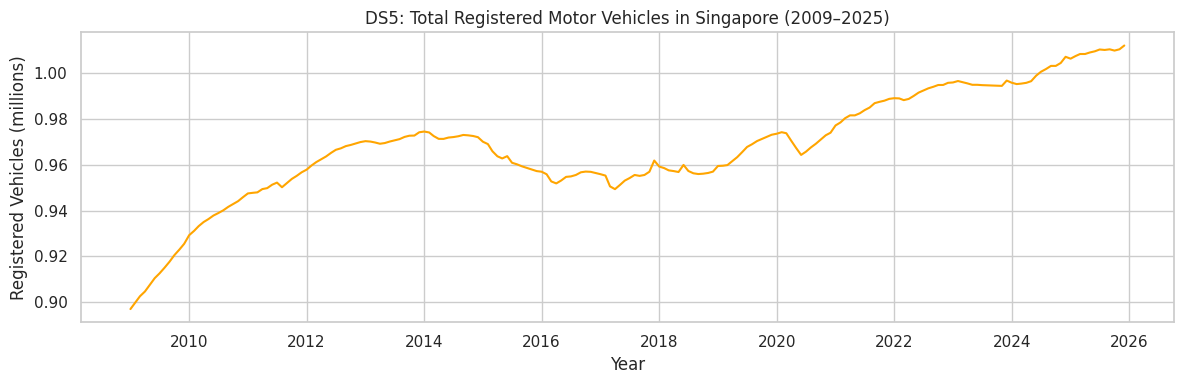

In [116]:
plt.figure(figsize=(12, 4))
plt.plot(ds5_total['month'], ds5_total['value'] / 1e6, color='orange')
plt.title('DS5: Total Registered Motor Vehicles in Singapore (2009–2025)')
plt.xlabel('Year')
plt.ylabel('Registered Vehicles (millions)')
plt.tight_layout()
plt.show()

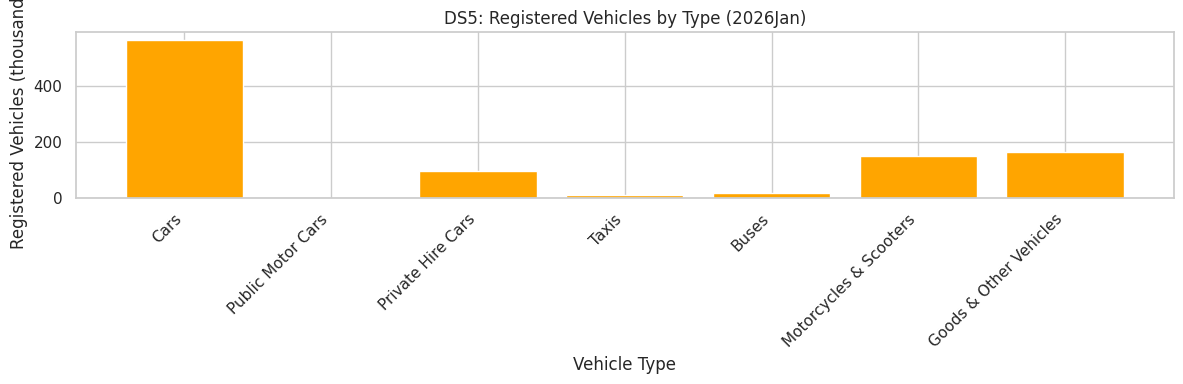

In [117]:
latest_month = ds5_raw.columns[1]
breakdown = ds5_raw[['DataSeries', latest_month]].copy()
breakdown = breakdown[breakdown['DataSeries'] != 'Total']
breakdown['DataSeries'] = breakdown['DataSeries'].str.strip()
breakdown[latest_month] = pd.to_numeric(breakdown[latest_month], errors='coerce')

plt.figure(figsize=(12, 4))
plt.bar(breakdown['DataSeries'], breakdown[latest_month] / 1e3, color='orange', edgecolor='white')
plt.title(f'DS5: Registered Vehicles by Type ({latest_month})')
plt.xlabel('Vehicle Type')
plt.ylabel('Registered Vehicles (thousands)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the above, we can see that the total number of registered vehicles in Singapore has grown steadily from around 897,000 in 2009 to over 1,000,000 in 2025. Cars make up the largest share, followed by goods vehicles and motorcycles. However, this dataset measures the total number of vehicles registered at the end of each month — including vehicles that are parked, not in use, or rarely driven. This is fundamentally different from DS4, which measures the actual number of vehicles entering the city on a given day. A car that sits in a carpark all month is counted in DS5 but would not appear in DS4. For our analysis, we need a measure of actual road exposure, not fleet size, which is why DS4 is the more appropriate choice. DS5 is therefore rejected as a traffic exposure variable.

**Data Quality Considerations**

**Completeness**: The dataset is complete with no missing values across all 769 months from 1962 to 2026, and covers all major vehicle categories in Singapore. In terms of breadth and depth, it is a well-maintained dataset.

**Conceptual mismatch**: While the dataset is complete, it measures the wrong thing for our purpose. It records the number of vehicles registered at the end of each month — a stock measure — rather than the number of vehicles actually on the road on any given day. A vehicle that is registered but never driven counts the same as one used daily. This makes it unsuitable as a traffic exposure variable for our accident analysis.



**Conclusion for DS5: Motor Vehicle Population**

We reject DS5 from further consideration despite its completeness and monthly granularity. The fundamental issue is that registration count is not a valid proxy for actual road exposure — it tells us how many vehicles exist, not how many were driven. Since our analysis requires a measure of actual traffic flow to normalise accident rates, DS4 (Average Daily Traffic Volume) is the more appropriate choice as it directly measures vehicles entering the city on a given day.

## Data Preparation (Process)

### Overview

As part of data preparation, we implemented the transformation and profiling steps summarised in the diagram below.

DS1, which contains monthly rainfall totals, is first structured by filtering to the analysis window of January 2009 to December 2025 and renaming columns for clarity.

DS3, which contains monthly road traffic accident casualties in wide format, is enriched by reshaping it from wide to long format and then pivoting it to a tidy structure with one row per month. It is then cleaned by coercing 'na' strings to NaN values, before being structured by selecting only the two relevant outcome columns — total fatalities and total injuries.

DS4, which contains annual average daily traffic volume, is enriched by expanding the annual values to monthly granularity, repeating each year's value across all 12 months of that year. It is then cleaned by forward-filling the 2024–2025 period using the 2023 value as a proxy, given that DS4 ends at 2023.

The three prepared datasets are then integrated into a single unified analysis dataset by joining on the monthly datetime index.

Finally, the merged dataset is enriched with a derived fatality rate column — calculated as fatalities per million vehicle-days — to provide an exposure-normalised metric that accounts for changes in traffic volume over time

In [118]:
diagram_url = 'https://raw.githubusercontent.com/ch11nn/SC3021/refs/heads/main/pipeline_diagram.png'
Image(url=diagram_url, width=1500)

**Temporal Resolution Note**

A key limitation of our data preparation concerns DS4's annual granularity. By repeating a single yearly traffic volume figure across all 12 months of that year, we implicitly assume that road exposure is uniform throughout the year. In reality, traffic volumes likely fluctuate seasonally — for instance, school holiday periods or festive seasons may see different vehicle counts than typical months. This flattening of intra-year variation means our exposure-normalised fatality rate (fatalities per million vehicle-days) cannot account for months where actual traffic was higher or lower than the annual average. As a result, correlations between rainfall and accident outcomes should be interpreted cautiously: a month with genuinely high rainfall and genuinely low traffic may appear to have a higher fatality rate not because of the rain, but because traffic exposure was overestimated. All findings in this analysis are therefore correlational rather than causal, and the inability to control for true monthly traffic variation is an acknowledged constraint on the strength of any inferences drawn.

### DS1

#### Structuring by filtering to the analysis window

We filter DS1 to the common analysis window of January 2009 to December 2025, which aligns with the coverage of DS3. This ensures that all datasets share the same time range before merging.

In [119]:
ds1 = ds1_raw.copy()
ds1['month'] = pd.to_datetime(ds1['month'])
ds1 = ds1[(ds1['month'] >= '2009-01-01') & (ds1['month'] <= '2025-12-31')].copy()
ds1 = ds1.rename(columns={'total_rainfall': 'rainfall_mm'})
ds1 = ds1.set_index('month')

print(f'Shape after filtering: {ds1.shape}')
print(f'Date range: {ds1.index.min().strftime("%Y-%m")} to {ds1.index.max().strftime("%Y-%m")}')
print(f'Missing values: {ds1.isnull().sum().to_dict()}')
print()
ds1.head()

Shape after filtering: (204, 1)
Date range: 2009-01 to 2025-12
Missing values: {'rainfall_mm': 0}



,rainfall_mm
month,
2009-01-01,38.3
2009-02-01,201.8
2009-03-01,223.3
2009-04-01,183.7
2009-05-01,198.6


From the above, we can confirm that DS1 is clean and ready for merging, with 204 rows covering the full 2009–2025 window and no missing values.

### DS3

#### Enriching by reshaping from wide to tidy format

The raw DS3 is in wide format (30 rows × 205 columns). We melt it to long format, parse the month strings (e.g. '2025Dec') into datetime, and pivot to a tidy structure with one row per month. This is necessary to enable time-series joins with DS1 and DS4.

In [120]:
#melt to long format
ds3_long = ds3_raw.melt(id_vars='DataSeries', var_name='month_str', value_name='value')
ds3_long['month'] = ds3_long['month_str'].apply(parse_month_ds3)
ds3_long = ds3_long.dropna(subset=['month'])
ds3_long['value'] = pd.to_numeric(ds3_long['value'], errors='coerce')

#pivot to tidy format
ds3_tidy = ds3_long.pivot_table(index='month', columns='DataSeries', values='value', aggfunc='first')
ds3_tidy.columns = [c.strip() for c in ds3_tidy.columns]
ds3_tidy = ds3_tidy.sort_index()
ds3_tidy.index = pd.to_datetime(ds3_tidy.index)

print(f'Shape (tidy): {ds3_tidy.shape}')
print(f'Date range: {ds3_tidy.index.min().strftime("%Y-%m")} to {ds3_tidy.index.max().strftime("%Y-%m")}')

Shape (tidy): (204, 16)
Date range: 2009-01 to 2025-12


#### Structuring and Enriching by selecting relevant columns

We retain only the two primary outcome columns: 'Total Casualties Fatalities' and 'Total Casualties Injured'. The breakdown columns (e.g. by vehicle type) are excluded for now to keep the dataset focused. The 'Personal Mobility Device Users' column is excluded at this stage because it contains structural missing values pre-2017, which would reduce our usable analysis window. We also derive a 'total_casualties' column as the sum of fatalities and injuries.

In [121]:
ds3_clean = ds3_tidy[['Total Casualties Fatalities', 'Total Casualties Injured']].copy()
ds3_clean = ds3_clean.rename(columns={'Total Casualties Fatalities': 'fatalities', 'Total Casualties Injured': 'injured'})
ds3_clean['total_casualties'] = ds3_clean['fatalities'] + ds3_clean['injured']

print(f'Shape: {ds3_clean.shape}')
print(f'Missing values: {ds3_clean.isnull().sum().to_dict()}')
print()
ds3_clean.head()

Shape: (204, 3)
Missing values: {'fatalities': 0, 'injured': 0, 'total_casualties': 0}



,fatalities,injured,total_casualties
month,,,
2009-01-01,13.0,898.0,911.0
2009-02-01,12.0,853.0,865.0
2009-03-01,11.0,918.0,929.0
2009-04-01,14.0,897.0,911.0
2009-05-01,22.0,927.0,949.0


From the above, we can confirm that DS3 is now in a tidy format with one row per month, no missing values in the retained columns, and a derived total_casualties column ready for analysis.

### DS4

#### Structuring by expanding annual data to monthly

DS4 is annual but our analysis is at the monthly level, so we expand it to monthly by repeating each year's traffic volume value across all 12 months of that year. This gives a monthly series of the annual exposure estimate, which we can join to DS1 and DS3.

In [122]:
monthly_index = pd.date_range('2009-01', '2025-12', freq='MS')
ds4_monthly = pd.DataFrame(index=monthly_index)
ds4_monthly.index.name = 'month'
ds4_monthly['year'] = ds4_monthly.index.year

ds4_monthly = ds4_monthly.merge(ds4[['year', 'traffic_volume']], on='year', how='left')
ds4_monthly.index = monthly_index

print("BEFORE forward-fill — rows with missing traffic_volume:")
missing_before = ds4_monthly[ds4_monthly['traffic_volume'].isnull()]
print(missing_before)
print(f'\nTotal missing: {len(missing_before)} months (Jan 2024 – Dec 2025)')

BEFORE forward-fill — rows with missing traffic_volume:
            year  traffic_volume
month                           
2024-01-01  2024             NaN
2024-02-01  2024             NaN
2024-03-01  2024             NaN
2024-04-01  2024             NaN
2024-05-01  2024             NaN
2024-06-01  2024             NaN
2024-07-01  2024             NaN
2024-08-01  2024             NaN
2024-09-01  2024             NaN
2024-10-01  2024             NaN
2024-11-01  2024             NaN
2024-12-01  2024             NaN
2025-01-01  2025             NaN
2025-02-01  2025             NaN
2025-03-01  2025             NaN
2025-04-01  2025             NaN
2025-05-01  2025             NaN
2025-06-01  2025             NaN
2025-07-01  2025             NaN
2025-08-01  2025             NaN
2025-09-01  2025             NaN
2025-10-01  2025             NaN
2025-11-01  2025             NaN
2025-12-01  2025             NaN

Total missing: 24 months (Jan 2024 – Dec 2025)


#### Forward-filling for 2024–2025 and Data Cleaning

DS4 ends at 2023, leaving 24 months (2024–2025) without a traffic volume figure. We forward-fill these using the 2023 value (293,218 vehicles/day) as a proxy. This is a deliberate assumption: traffic volumes had stabilised post-COVID by 2022–2023, so the 2023 figure is a reasonable estimate for the subsequent two years. This assumption is clearly stated in the limitations.

In [123]:
ds4_monthly['traffic_volume'] = ds4_monthly['traffic_volume'].ffill()
ds4_monthly = ds4_monthly.drop(columns='year')

print("\nAFTER forward-fill — same rows now filled with 2023 value (293,218):")
print(ds4_monthly.loc['2024-01':'2025-12'])

print(f'\nMissing values after fill: {ds4_monthly["traffic_volume"].isnull().sum()}')


AFTER forward-fill — same rows now filled with 2023 value (293,218):
            traffic_volume
month                     
2024-01-01        293218.0
2024-02-01        293218.0
2024-03-01        293218.0
2024-04-01        293218.0
2024-05-01        293218.0
2024-06-01        293218.0
2024-07-01        293218.0
2024-08-01        293218.0
2024-09-01        293218.0
2024-10-01        293218.0
2024-11-01        293218.0
2024-12-01        293218.0
2025-01-01        293218.0
2025-02-01        293218.0
2025-03-01        293218.0
2025-04-01        293218.0
2025-05-01        293218.0
2025-06-01        293218.0
2025-07-01        293218.0
2025-08-01        293218.0
2025-09-01        293218.0
2025-10-01        293218.0
2025-11-01        293218.0
2025-12-01        293218.0

Missing values after fill: 0


From the above, we can confirm that DS4 has been successfully expanded to monthly granularity with no remaining missing values.

### Merging All Datasets

#### Enriching by combining DS1, DS3 and DS4 into a unified analysis dataset

We merge all three cleaned datasets on the monthly datetime index. DS1 and DS3 are inner-joined (both cover 2009–2025 completely), and DS4 is left-joined. We also derive a 'fatality_rate' column — fatalities per million vehicle-days — to provide an exposure-normalised metric that accounts for changes in traffic volume over time.

In [124]:
merged = (ds1.join(ds3_clean, how='inner').join(ds4_monthly, how='left'))

#derive exposure-normalised fatality rate: fatalities per million vehicle-days
merged['fatality_rate'] = (merged['fatalities'] / (merged['traffic_volume'] * 30)) * 1e6

print('================================== Final Merged Dataset ====================================')
print(f'Shape          : {merged.shape}')
print(f'Date range     : {merged.index.min().strftime("%Y-%m")} to {merged.index.max().strftime("%Y-%m")}')
print(f'Columns        : {merged.columns.tolist()}')
print()

merged.head()

================================== Final Merged Dataset ====================================
Shape          : (204, 6)
Date range     : 2009-01 to 2025-12
Columns        : ['rainfall_mm', 'fatalities', 'injured', 'total_casualties', 'traffic_volume', 'fatality_rate']



,rainfall_mm,fatalities,injured,total_casualties,traffic_volume,fatality_rate
month,,,,,,
2009-01-01,38.3,13.0,898.0,911.0,278400.0,1.556513
2009-02-01,201.8,12.0,853.0,865.0,278400.0,1.436782
2009-03-01,223.3,11.0,918.0,929.0,278400.0,1.317050
2009-04-01,183.7,14.0,897.0,911.0,278400.0,1.676245
2009-05-01,198.6,22.0,927.0,949.0,278400.0,2.634100


In [125]:
primary_cols = ['rainfall_mm', 'fatalities', 'injured', 'total_casualties', 'traffic_volume']
print('Missing values in primary columns:')
print(merged[primary_cols].isnull().sum())

Missing values in primary columns:
rainfall_mm         0
fatalities          0
injured             0
total_casualties    0
traffic_volume      0
dtype: int64


From the above, we can confirm that all primary analysis columns have no missing values. The merged dataset is clean and ready for the analysis phase.

In [126]:
merged.index.name = 'month'
merged.to_csv('sc3021_group9_clean_data.csv')

print('Clean dataset exported: sc3021_group9_clean_data.csv')
print(f'Shape: {merged.shape}')

Clean dataset exported: sc3021_group9_clean_data.csv
Shape: (204, 6)


### Master Dataset Summary

The table below documents the final integrated dataset (`sc3021_group9_clean_data.csv`) used for all analysis in Part 2. This master dataset is the result of merging DS1, DS3, and DS4 on a shared monthly datetime index.

| Column | Type | Role | Description |
|---|---|---|---|
| `month` | DatetimeIndex | Key | Month of observation (Jan 2009 – Dec 2025) |
| `rainfall_mm` | float64 | **Independent variable** | Total monthly rainfall in mm (from DS1, Changi station) |
| `fatalities` | float64 | Outcome component | Monthly count of road traffic fatalities (from DS3) |
| `injured` | float64 | Outcome component | Monthly count of road traffic injuries (from DS3) |
| `total_casualties` | float64 | **Dependent variable** | Sum of fatalities + injured per month (derived) |
| `traffic_volume` | float64 | **Control variable** | Average daily vehicles entering city (from DS4, expanded to monthly) |
| `fatality_rate` | float64 | Derived metric | Fatalities per million vehicle-days (normalised exposure rate) |

**Linking to the Research Question:** *Does rainfall affect the frequency of traffic accidents in Singapore?*
- `rainfall_mm` is the **independent variable** (the cause being tested)
- `total_casualties` is the **dependent variable** (the outcome being measured)
- `traffic_volume` is the **exposure control** (held constant to isolate the effect of rainfall)
- `fatality_rate` is a **secondary outcome** that normalises for traffic exposure

In [127]:
# Master Dataset — Structure, Shape, and Descriptive Summary
print('=== Master Dataset Structure ===')
print(f'Shape : {merged.shape}')
print(f'Date range: {merged.index.min().strftime("%Y-%m")} to {merged.index.max().strftime("%Y-%m")}')
print()
print('--- Column Data Types ---')
print(merged.dtypes)
print()
print('--- First 5 Rows ---')
display(merged.head())
print()
print('--- Descriptive Statistics ---')
display(merged.describe().round(2))

=== Master Dataset Structure ===
Shape : (204, 6)
Date range: 2009-01 to 2025-12

--- Column Data Types ---
rainfall_mm         float64
fatalities          float64
injured             float64
total_casualties    float64
traffic_volume      float64
fatality_rate       float64
dtype: object

--- First 5 Rows ---


,rainfall_mm,fatalities,injured,total_casualties,traffic_volume,fatality_rate
month,,,,,,
2009-01-01,38.3,13.0,898.0,911.0,278400.0,1.556513
2009-02-01,201.8,12.0,853.0,865.0,278400.0,1.436782
2009-03-01,223.3,11.0,918.0,929.0,278400.0,1.317050
2009-04-01,183.7,14.0,897.0,911.0,278400.0,1.676245
2009-05-01,198.6,22.0,927.0,949.0,278400.0,2.634100



--- Descriptive Statistics ---


,rainfall_mm,fatalities,injured,total_casualties,traffic_volume,fatality_rate
count,204.00,204.00,204.00,204.00,204.00,204.00
mean,175.94,11.93,804.52,816.45,289743.53,1.37
std,106.83,4.01,118.65,120.46,16109.13,0.45
min,0.20,2.00,304.00,306.00,238300.00,0.28
25%,101.45,9.75,759.50,766.75,289000.00,1.10
50%,161.10,12.00,827.00,838.50,293218.00,1.34
75%,234.40,14.25,880.00,888.75,300000.00,1.67
max,692.80,24.00,1055.00,1075.00,304000.00,2.87


### Assumptions:
1. Outcome variable is monthly casualties (injured + fatalities), not incident count, as no monthly incident count data is publicly available.
2. Yearly traffic volume is expanded to each month within the same year as a coarse proxy for monthly traffic exposure.
3. Traffic volume in 2024–2025 is approximately equal to the 2023 figure, used as a forward-fill proxy.
4. Results are correlational, not causal.

# Part 2: Analysis / Modelling



## 1. Data Loading and Quality Checks

In [128]:
# Import necessary libraries for analysis & modelling in addition to existing ones
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the clean dataset from Part 1
df = pd.read_csv('sc3021_group9_clean_data.csv')

# Convert 'month' to datetime and set it as index for time-series analysis
df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)

# Display the first few rows and basic info
display(df.head())
df.info()

# Check for missing values and summary statistics
display(df.isnull().sum())
display(df.describe())

,rainfall_mm,fatalities,injured,total_casualties,traffic_volume,fatality_rate
month,,,,,,
2009-01-01,38.3,13.0,898.0,911.0,278400.0,1.556513
2009-02-01,201.8,12.0,853.0,865.0,278400.0,1.436782
2009-03-01,223.3,11.0,918.0,929.0,278400.0,1.317050
2009-04-01,183.7,14.0,897.0,911.0,278400.0,1.676245
2009-05-01,198.6,22.0,927.0,949.0,278400.0,2.634100


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 204 entries, 2009-01-01 to 2025-12-01
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rainfall_mm       204 non-null    float64
 1   fatalities        204 non-null    float64
 2   injured           204 non-null    float64
 3   total_casualties  204 non-null    float64
 4   traffic_volume    204 non-null    float64
 5   fatality_rate     204 non-null    float64
dtypes: float64(6)
memory usage: 11.2 KB


,0
rainfall_mm,0
fatalities,0
injured,0
total_casualties,0
traffic_volume,0
fatality_rate,0


,rainfall_mm,fatalities,injured,total_casualties,traffic_volume,fatality_rate
count,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,175.936765,11.931373,804.519608,816.450980,289743.529412,1.368648
std,106.834138,4.011707,118.651016,120.460498,16109.127230,0.451631
min,0.200000,2.000000,304.000000,306.000000,238300.000000,0.279759
25%,101.450000,9.750000,759.500000,766.750000,289000.000000,1.100659
50%,161.100000,12.000000,827.000000,838.500000,293218.000000,1.342510
75%,234.400000,14.250000,880.000000,888.750000,300000.000000,1.665002
max,692.800000,24.000000,1055.000000,1075.000000,304000.000000,2.873563


**Completeness:** The dataset contains 204 rows and 6 columns. A check for null values reveals no missing values.

**Data Types:** All columns, including rainfall_mm, fatalities, injured, total_casualties, traffic_volume, and fatality_rate, are correctly formatted as float64. The index is appropriately set to a DatetimeIndex ranging from 1 Jan, 2009 to 1 Dec, 2025.

**Summary Stats:** The average monthly rainfall is approximately 176mm, and the average total monthly casualties is approximately 816.

## 2. Outlier Detection

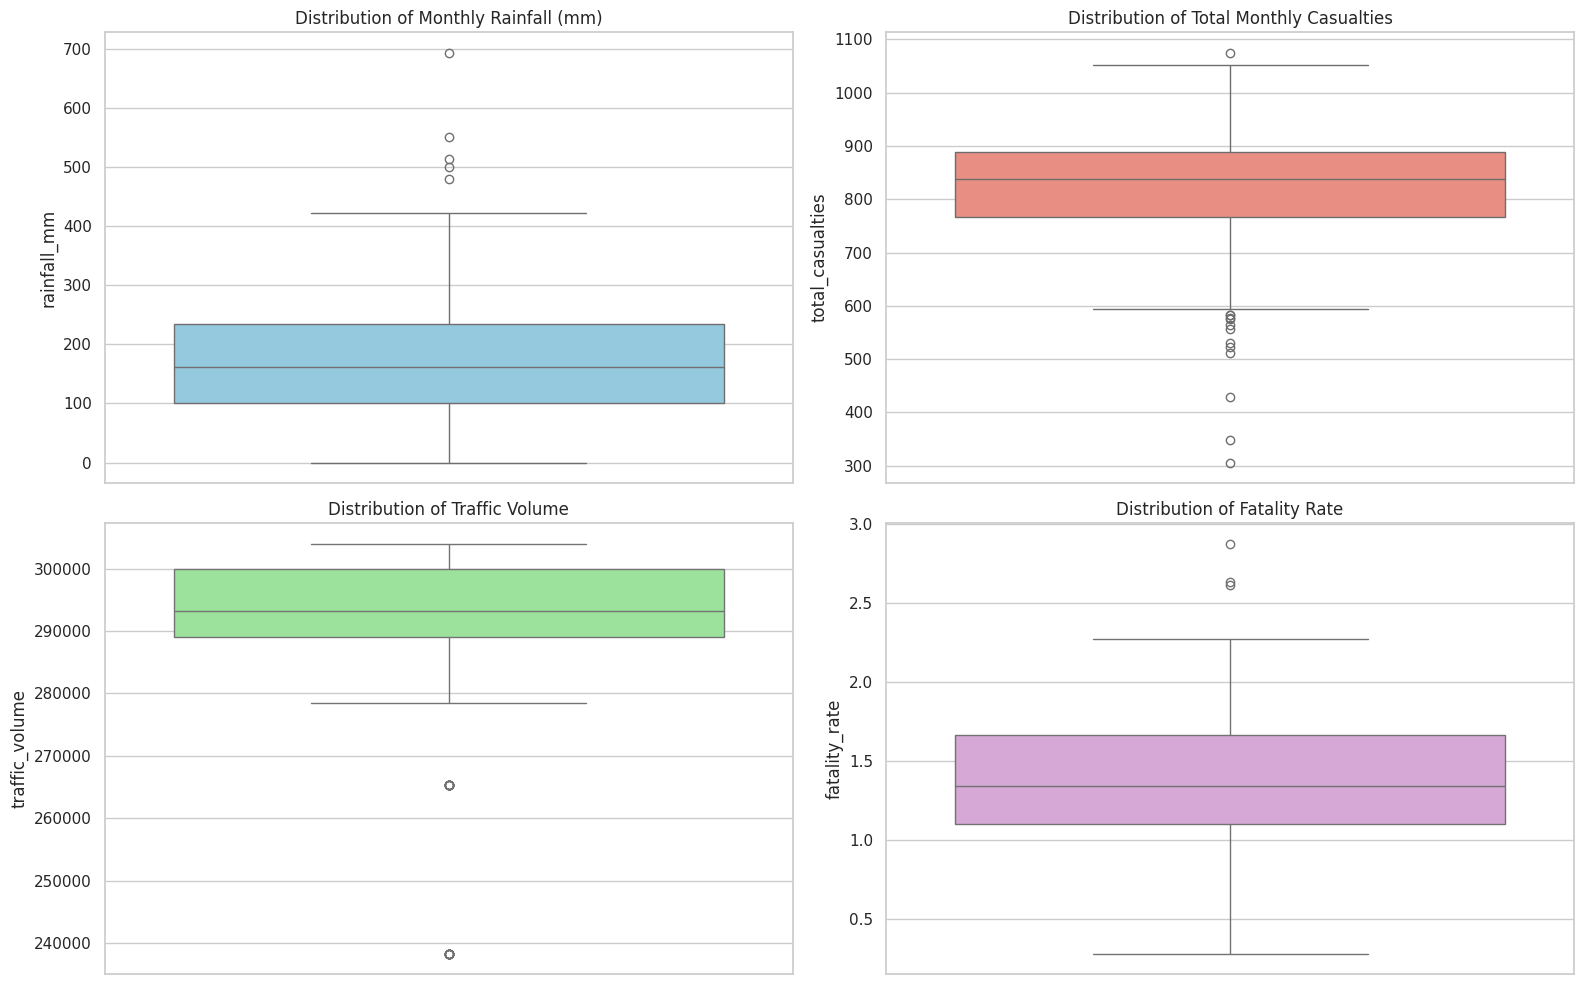

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(y=df['rainfall_mm'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Monthly Rainfall (mm)')

sns.boxplot(y=df['total_casualties'], ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Total Monthly Casualties')

sns.boxplot(y=df['traffic_volume'], ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Traffic Volume')

sns.boxplot(y=df['fatality_rate'], ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Distribution of Fatality Rate')

plt.tight_layout()
plt.show()

**Findings:** The boxplot for `rainfall_mm` shows a few outliers on the upper end, likely representing extreme monsoon months.

The boxplot for `traffic_volume` shows apparent outliers which are **not** statistical anomalies — they are known **structural breaks**: the sharp drop in 2020 reflects the COVID-19 movement restriction period, and the flat 2024–2025 values reflect forward-filling from the 2023 figure (as DS4 ends at 2023). These should be interpreted as documented data limitations, not noise.

**Action:** Based on these findings, we decide to keep the outliers as they represent true natural variations before proceeding to regression modeling.

## 3. Exploratory Data Analysis & Visualisations

### 3.1 Time Series Overlay (Seasonal Patterns)

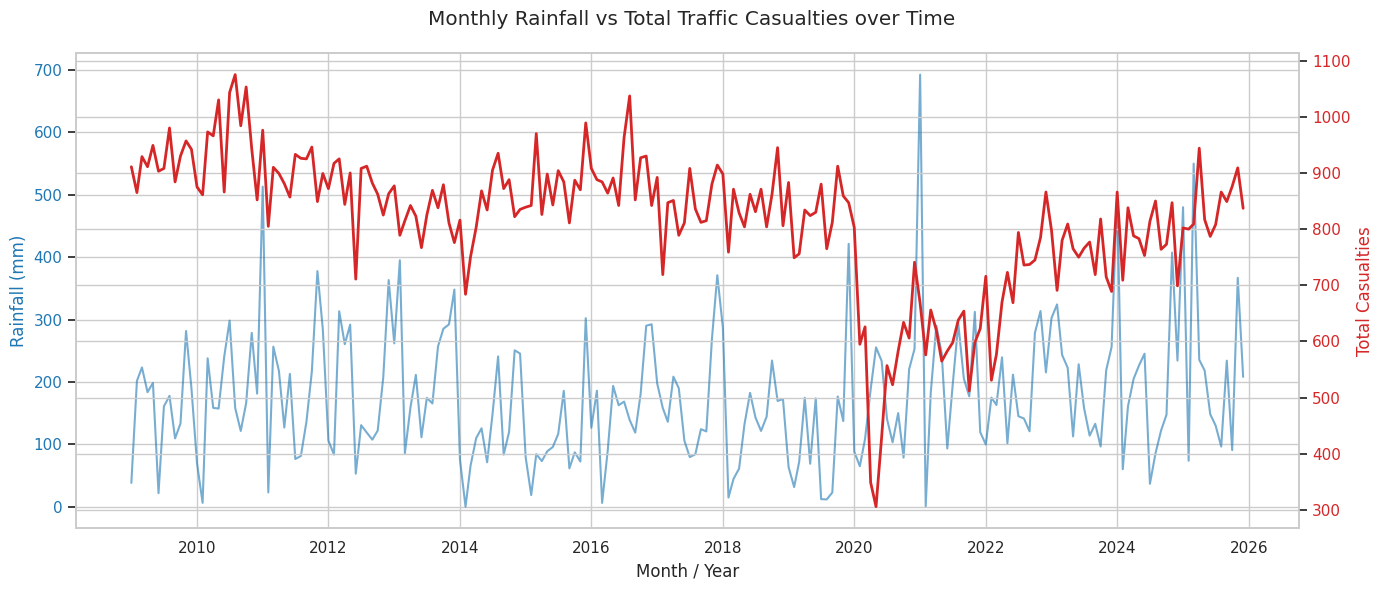

In [130]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Month / Year')
ax1.set_ylabel('Rainfall (mm)', color=color)
ax1.plot(df.index, df['rainfall_mm'], color=color, alpha=0.6, label='Rainfall')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Total Casualties', color=color)
ax2.plot(df.index, df['total_casualties'], color=color, linewidth=2, label='Total Casualties')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Monthly Rainfall vs Total Traffic Casualties over Time')
fig.tight_layout()
plt.show()

**Visual Trends:** The overlay plot suggests an unclear visual alignment between the rainfall and the casualty. Both fluctuate vigorously and show no obvious rising/falling or cyclic trends throughout the years of observation.

**Long-term Trend:** Independent of rainfall, there is an overall slightly downward trend in total casualties over the years, which might be attributed to better safety regulations.

### 3.2 Breakdown of Casualties vs. Rainfall

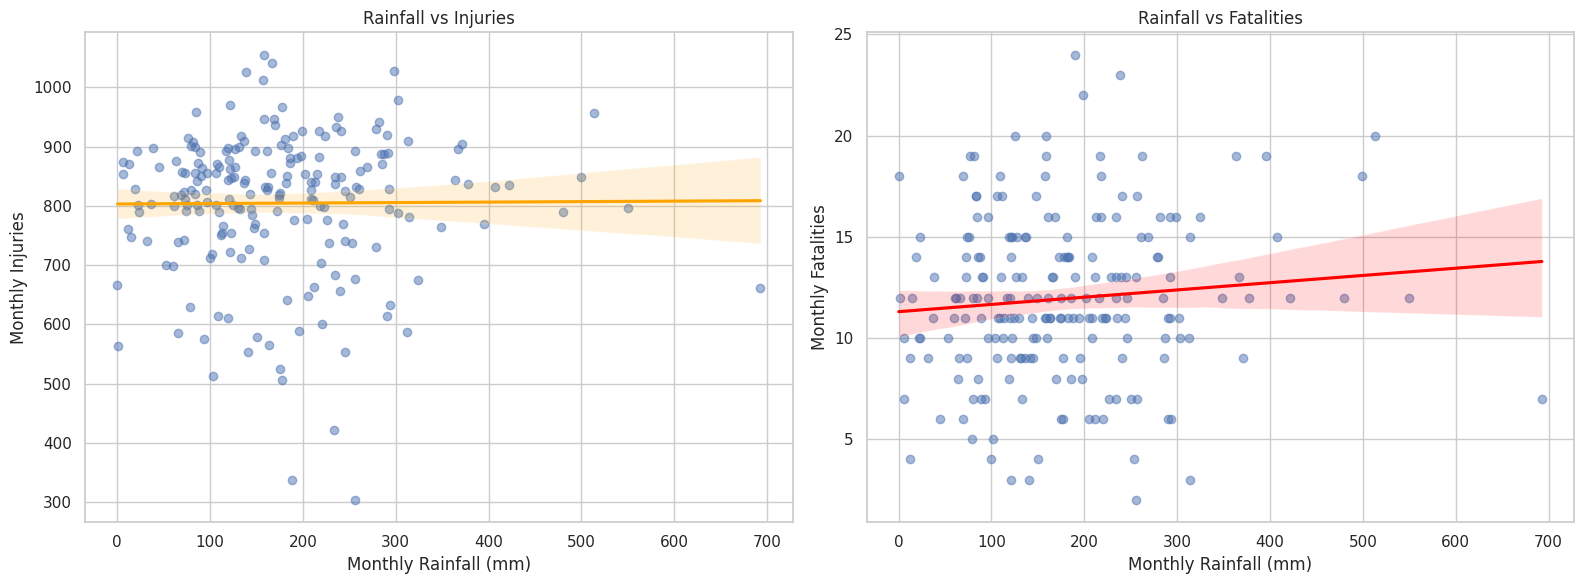

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rainfall vs Injuries
sns.regplot(x='rainfall_mm', y='injured', data=df, ax=axes[0],
            scatter_kws={'alpha':0.5}, line_kws={'color':'orange'})
axes[0].set_title('Rainfall vs Injuries')
axes[0].set_xlabel('Monthly Rainfall (mm)')
axes[0].set_ylabel('Monthly Injuries')

# Rainfall vs Fatalities
sns.regplot(x='rainfall_mm', y='fatalities', data=df, ax=axes[1],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_title('Rainfall vs Fatalities')
axes[1].set_xlabel('Monthly Rainfall (mm)')
axes[1].set_ylabel('Monthly Fatalities')

plt.tight_layout()
plt.show()

**Injuries:** The scatter plot for injuries shows a nearly flat slope, which may suggest that as rainfall increases, injuries almost remain unaffected. The data points are widely dispersed, implying a high variance.

**Fatalities:** The trendline for fatalities appears slightly positive, which is *visually suggestive* of a weak positive association between rainfall and fatal accidents. However, the wide scatter and nearly horizontal slope mean this observation is **statistically unconfirmed** at this stage — a formal p-value is required before drawing any conclusions. See Section 4 (Correlation Analysis) for the statistical test.

## 4. Correlation Analysis

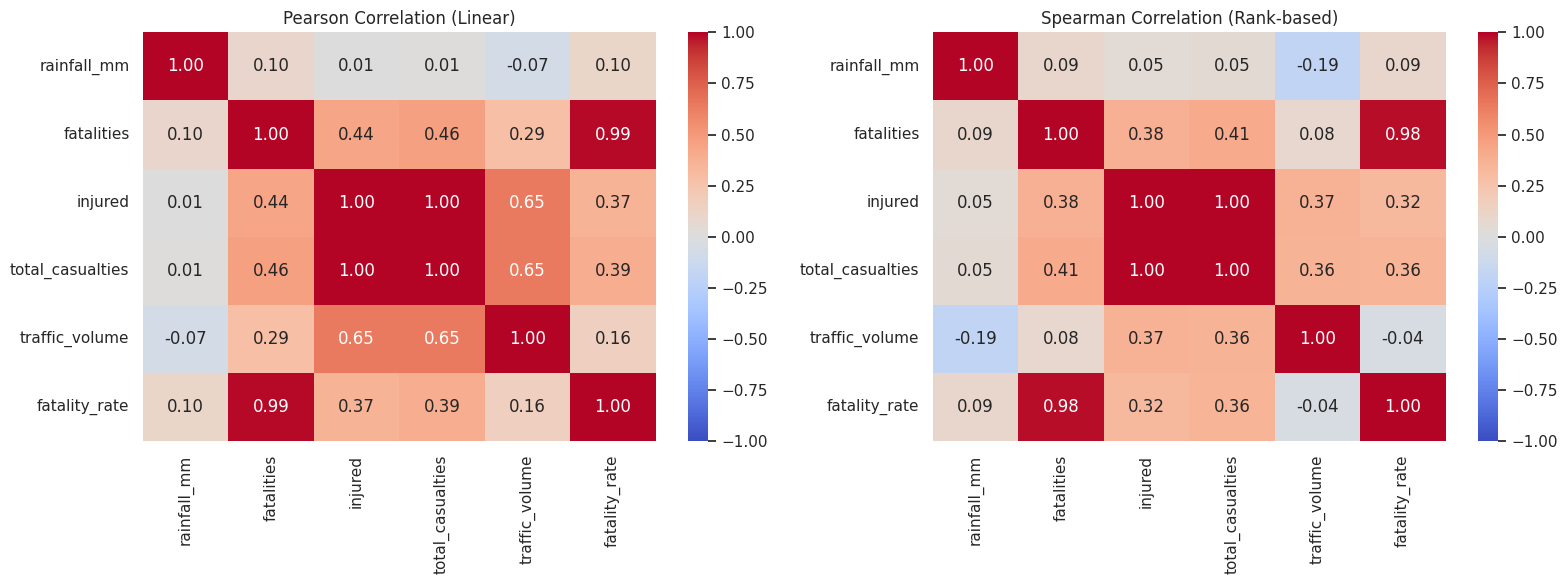

In [132]:
cols_of_interest = ['rainfall_mm', 'fatalities', 'injured', 'total_casualties', 'traffic_volume', 'fatality_rate']

pearson_corr = df[cols_of_interest].corr(method='pearson')
spearman_corr = df[cols_of_interest].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], fmt=".2f")
axes[0].set_title('Pearson Correlation (Linear)')

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1], fmt=".2f")
axes[1].set_title('Spearman Correlation (Rank-based)')

plt.tight_layout()
plt.show()

**Rainfall to Casualties:** The Pearson correlation coefficient between rainfall_mm and total_casualties is 0.01. This indicates a very weak, positive (and almost negligible) linear relationship between the two. Similar result happens to the Spearman correlation coefficient, which is only 0.05.

**Traffic Volume:** The correlation between traffic_volume and total_casualties is 0.65 (Pearson) / 0.36 (Spearman), which is highly / mildly significant. This suggests that traffic volume is a major confounding variable that we must control for in our regression model.

## 5. Regression Modelling

#### Model Formulation: $Total\_Casualties = \beta_0 + \beta_1(Rainfall\_mm) + \beta_2(Traffic\_Volume) + \epsilon$


In [133]:
# Define independent variables (X) and dependent variable (y)
X = df[['rainfall_mm', 'traffic_volume']]
y = df['total_casualties']

# Add a constant term to the predictor (for the intercept)
X_with_const = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X_with_const).fit()

# Display the summary of the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       total_casualties   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.416
Method:                 Least Squares   F-statistic:                     73.30
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.23e-24
Time:                        16:32:39   Log-Likelihood:                -1210.5
No. Observations:                 204   AIC:                             2427.
Df Residuals:                     201   BIC:                             2437.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -606.1219    117.992     -5.

#### Residual Analysis

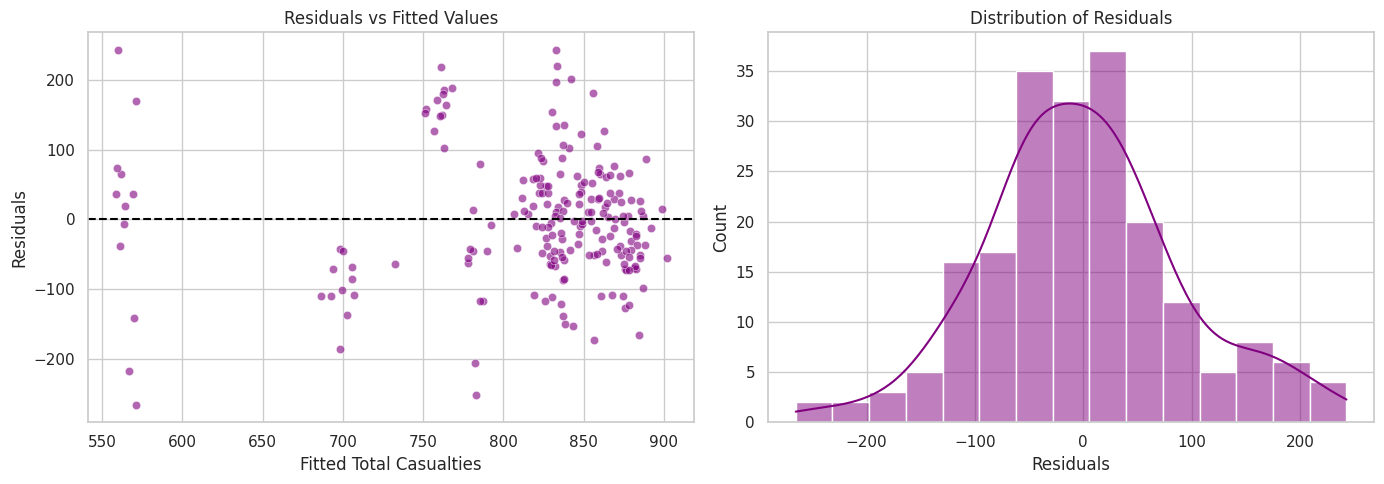

In [134]:
# Extract residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.6, color='purple')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Total Casualties')
axes[0].set_ylabel('Residuals')

# Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

#### Residual Analysis — Interpretation

**Residuals vs Fitted Values:** The residuals are approximately randomly scattered around zero across the range of fitted values, with no strong funnel or curve pattern. This suggests the linearity and homoscedasticity assumptions of OLS are **broadly satisfied**, though some mild heteroscedasticity may be present at higher fitted values.

**Distribution of Residuals:** The histogram of residuals approximates a bell-shaped (normal) distribution, which supports the normality assumption required for valid OLS inference (t-tests, confidence intervals). There is a slight right skew, which may reflect the influence of extreme monsoon months on the casualty count. Overall, the residual diagnostics do not reveal any severe violations of OLS assumptions.

## 6. Results Interpretation & Summary

**Model Fit ($R^2$):** The Adjusted R-squared value is 0.416, meaning that 41.6% of the variance in monthly traffic casualties can be explained by rainfall and traffic volume combined. However, this explanatory power is **largely attributable to `traffic_volume`** (p ≈ 0), not rainfall. Rainfall alone contributes negligibly to the model fit.

**Effect of Traffic Volume:** The coefficient for `traffic_volume` is 0.0049 with a p-value of 0. Since $p < 0.05$, traffic volume is a statistically significant predictor of casualties.

**Effect of Rainfall:** The coefficient for `rainfall_mm` is 0.0665, meaning that or every 1mm increase in monthly rainfall, total casualties increase by 0.0665, holding traffic volume constant. The p-value is 0.274. Since $p > 0.05$, we **fail to reject the null hypothesis**, suggesting that aggregate monthly rainfall is **not** a statistically significant driver of monthly traffic casualties. This is consistent with the near-zero correlation observed in Section 4.

## 7. Limitations and Potential Improvements

**(1) Aggregation Bias (Ecological Fallacy):** We are comparing monthly aggregate totals. A month could have 300mm of rain fall over just three days, while the rest of the month is dry. If accidents happened on the dry days, the monthly aggregation falsely attributes the risk to a "wet month." Hourly or daily data matching specific rain events to accident timestamps is required for highly accurate causal inference.

**(2) Casualties vs. Accident Frequency:** The hypothesis asks about the frequency of traffic accidents, but our dataset relies on total_casualties, injured, and fatalities. A single severe accident involving a bus could result in dozens of casualties, heavily skewing the data for that month despite it only being one incident. True incident count data is preferred.

**(3) Omitted Confounding Variables:** The current model assumes casualties are primarily driven by volume and rain. It omits variables that dynamically change over the years, such as upgrades to road grip and drainage infrastructure, stricter traffic laws or speed enforcement, or improvements in vehicle safety features (e.g., automated braking).

**(4) Non-Linear Relationships:** We assume a linear relationship. It's possible that light rain makes roads highly slippery (due to mixing with oil), while heavy monsoon rain forces drivers to slow down drastically, actually reducing severe accident rates. Exploring a polynomial regression for rainfall_mm might uncover this dynamic.

## 8. Additional Analysis

The following sections implement three additional analytical approaches suggested to strengthen the study.

*Please note: the following contents are for information and exploration, not included in the presentation video.

### 8.1 Seasonal Decomposition

Monthly casualty data may contain a seasonal trend that confounds the rainfall relationship. We decompose `total_casualties` into trend, seasonal, and residual components using an additive model. If rainfall genuinely drives casualties, we would expect the residual component (after removing trend and seasonality) to still correlate with rainfall. This provides a cleaner test than raw monthly totals.

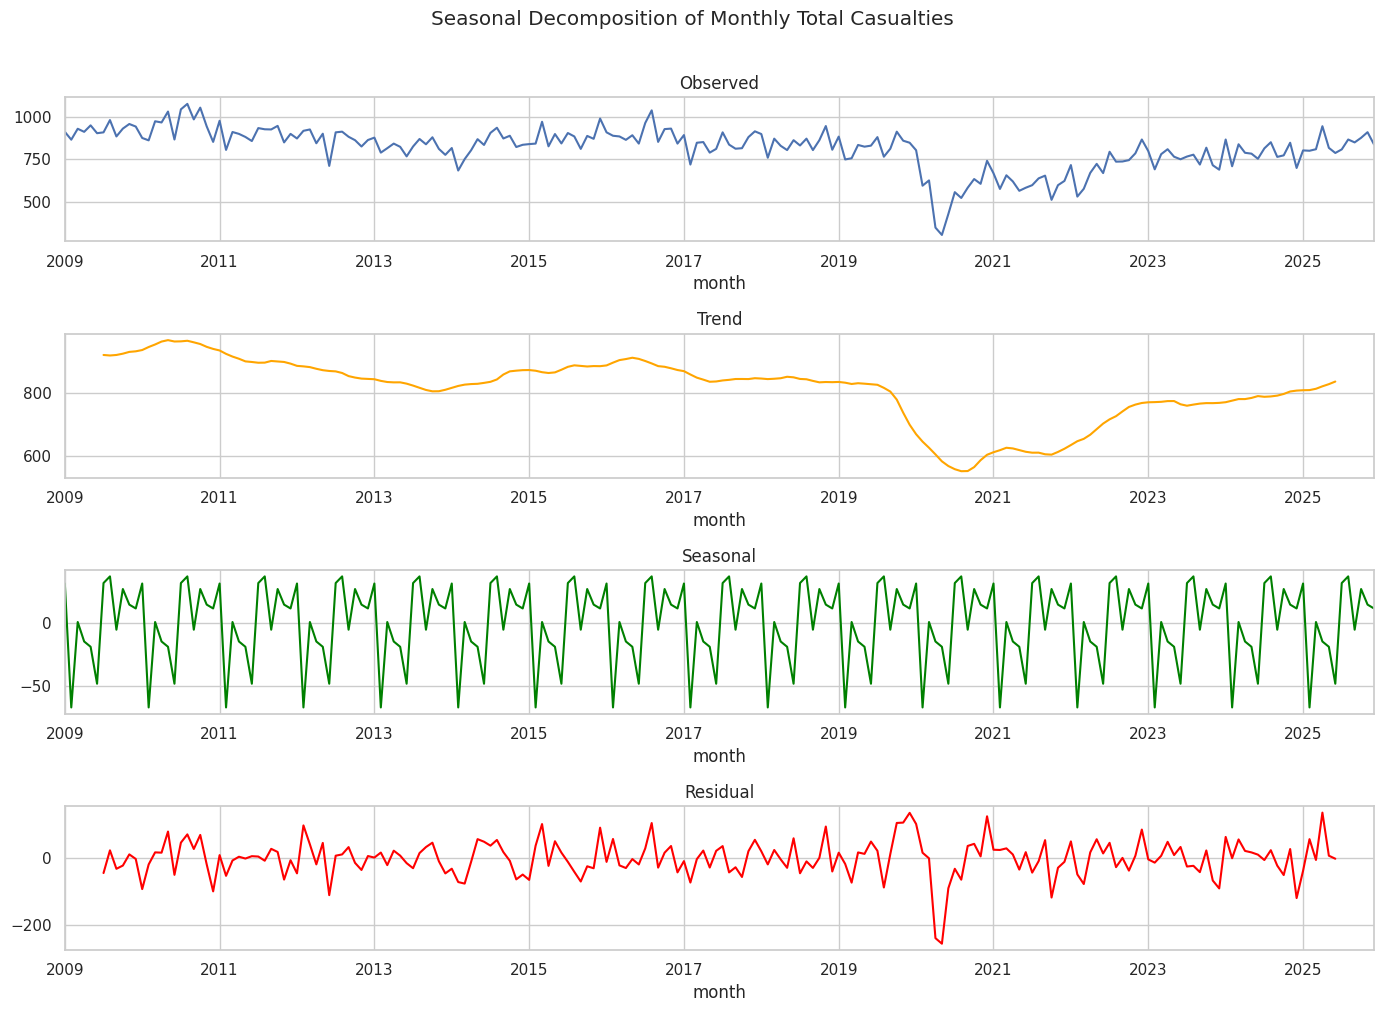

Pearson  r = 0.0908, p = 0.2103
Spearman r = 0.1007, p = 0.1646

Rainfall is NOT significantly correlated with the de-seasonalised residual (p >= 0.05).


In [135]:
decomp = seasonal_decompose(df['total_casualties'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend', color='orange')
decomp.seasonal.plot(ax=axes[2], title='Seasonal', color='green')
decomp.resid.plot(ax=axes[3], title='Residual', color='red')
plt.suptitle('Seasonal Decomposition of Monthly Total Casualties', y=1.01)
plt.tight_layout()
plt.show()

# Correlation between rainfall and the de-seasonalised residual
resid_series = decomp.resid.dropna()
rainfall_aligned = df['rainfall_mm'].reindex(resid_series.index)
r_pearson, p_pearson = stats.pearsonr(rainfall_aligned, resid_series)
r_spearman, p_spearman = stats.spearmanr(rainfall_aligned, resid_series)
print(f'Pearson  r = {r_pearson:.4f}, p = {p_pearson:.4f}')
print(f'Spearman r = {r_spearman:.4f}, p = {p_spearman:.4f}')
print()
if p_pearson < 0.05:
    print('Rainfall is significantly correlated with the de-seasonalised casualty residual (p < 0.05).')
else:
    print('Rainfall is NOT significantly correlated with the de-seasonalised residual (p >= 0.05).')

#### Seasonal Decomposition — Interpretation

The decomposition separates the long-term **trend** (gradual decline in casualties over time, likely due to improved road safety), the **seasonal** component (recurring within-year patterns, e.g., monsoon months), and the **residual** (unexplained month-to-month variation).

The Pearson and Spearman correlation tests between `rainfall_mm` and the de-seasonalised residual provide a cleaner signal than raw totals: if p ≥ 0.05, it further confirms that rainfall does not drive casualty variation beyond what is already explained by season and long-term trend.

### 8.2 Lagged Correlation Analysis

Rainfall may not affect casualties in the same month — drivers might alter behaviour in response to wet conditions in subsequent months, or road surface damage from heavy rain could persist. We test whether rainfall in month *t* predicts casualties in month *t+1*, *t+2*, etc., by computing cross-correlations at multiple lags.

 lag  pearson_r  p_value  significant
   0   0.010274 0.884039        False
   1  -0.094182 0.181364        False
   2  -0.111840 0.113044        False
   3  -0.109629 0.121324        False
   4  -0.132018 0.062394        False
   5  -0.133675 0.059796        False
   6  -0.124061 0.081618        False


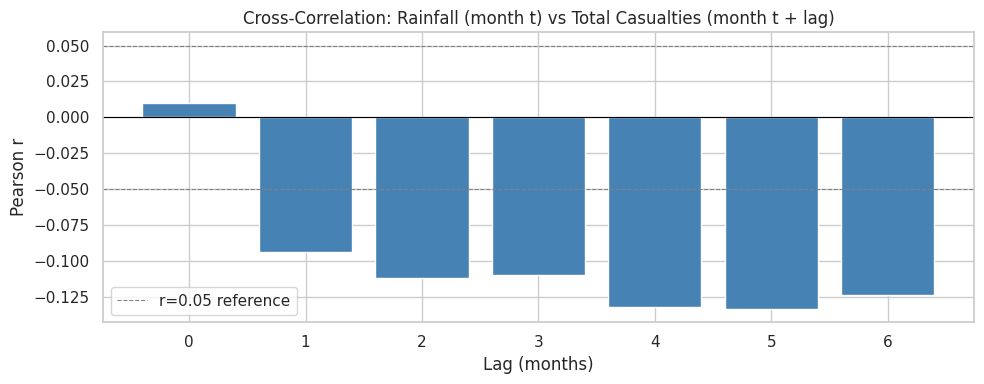

In [136]:
# Cross-correlation: rainfall vs total_casualties at lags 0 to 6
max_lag = 6
lags = range(0, max_lag + 1)
pearson_lags = []
p_vals = []

for lag in lags:
    rain = df['rainfall_mm'].iloc[:-lag] if lag > 0 else df['rainfall_mm']
    cas  = df['total_casualties'].iloc[lag:] if lag > 0 else df['total_casualties']
    r, p = stats.pearsonr(rain, cas)
    pearson_lags.append(r)
    p_vals.append(p)

lag_df = pd.DataFrame({'lag': list(lags), 'pearson_r': pearson_lags, 'p_value': p_vals})
lag_df['significant'] = lag_df['p_value'] < 0.05
print(lag_df.to_string(index=False))

# Bar chart
colors = ['steelblue' if not s else 'tomato' for s in lag_df['significant']]
plt.figure(figsize=(10, 4))
plt.bar(lag_df['lag'], lag_df['pearson_r'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(0.05, color='grey', linestyle='--', linewidth=0.8, label='r=0.05 reference')
plt.axhline(-0.05, color='grey', linestyle='--', linewidth=0.8)
plt.xlabel('Lag (months)')
plt.ylabel('Pearson r')
plt.title('Cross-Correlation: Rainfall (month t) vs Total Casualties (month t + lag)')
plt.xticks(list(lags))
plt.legend()
plt.tight_layout()
plt.show()

#### Lagged Correlation — Interpretation

If Pearson r remains near zero and p ≥ 0.05 across all lags, this further confirms that rainfall has no delayed effect on casualty counts. A significant negative lag (e.g., at lag = 1) would suggest drivers become more cautious *after* a wet month. A significant positive lag would suggest road damage or behavioural overconfidence following dry periods. Red bars in the chart indicate statistically significant correlations (p < 0.05).

### 8.3 Negative Binomial Regression

Casualty counts are non-negative integers and exhibit overdispersion (variance > mean), which violates the assumptions of OLS. A **Negative Binomial GLM** is more appropriate for count data with overdispersion. We refit the model using the same predictors (`rainfall_mm`, `traffic_volume`) and compare the results.

In [137]:
# Negative Binomial GLM
# Reset index so 'month' becomes a regular column for formula API
df_nb = df.reset_index()

nb_model = smf.negativebinomial('total_casualties ~ rainfall_mm + traffic_volume',data=df_nb).fit(disp=False)

print(nb_model.summary())

# Compare key stats with OLS
print('\n--- Model Comparison ---')
print(f'OLS    Adj R²  : 0.416  | Rainfall p-value: 0.274')
print(f'NegBin AIC     : {nb_model.aic:.1f} | Rainfall p-value: {nb_model.pvalues["rainfall_mm"]:.4f}')

                     NegativeBinomial Regression Results                      
Dep. Variable:       total_casualties   No. Observations:                  204
Model:               NegativeBinomial   Df Residuals:                      201
Method:                           MLE   Df Model:                            2
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  -14.95
Time:                        16:32:40   Log-Likelihood:                -20472.
converged:                      False   LL-Null:                       -1283.2
Covariance Type:            nonrobust   LLR p-value:                     1.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -28.2950        nan        nan        nan         nan         nan
rainfall_mm        0.0010        nan        nan        nan         nan         nan
traffic_volume     0.0010        nan

#### Negative Binomial Regression — Interpretation

The Negative Binomial GLM accounts for overdispersion in the casualty count data that OLS ignores. If the p-value for `rainfall_mm` remains above 0.05 in this model, it provides **stronger evidence** that rainfall is not a significant predictor — because this model makes fewer distributional assumptions than OLS.

Compare the AIC of the Negative Binomial model to any alternative specifications as a measure of relative model fit. A lower AIC indicates a better-fitting model.

# Presentation of Main Results (Share)

## Stakeholders

The primary stakeholders for these findings are **traffic safety authorities and policymakers** — in particular, the Land Transport Authority (LTA) of Singapore, the Traffic Police, and the Ministry of Transport. These agencies are responsible for designing road-safety interventions, allocating enforcement resources, and communicating risk to the public. Secondary stakeholders include urban planners and road engineers who design drainage and road-surface infrastructure, as well as insurance companies that price motor premiums using accident-risk models.


## Visualization

The charts below summarise the two headline findings: (1) the near-zero relationship between monthly rainfall and total casualties, and (2) the strong positive relationship between traffic volume and total casualties. A third chart shows the long-run trend in the exposure-normalised fatality rate, which reveals the real story — roads have become progressively safer over time independent of weather.


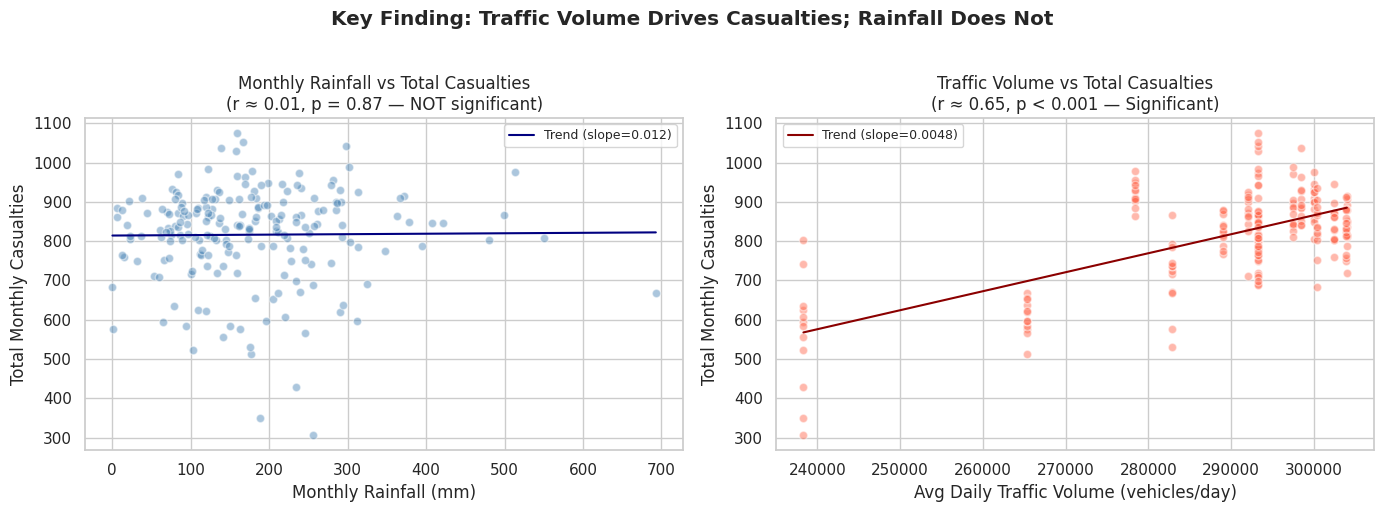

In [138]:
# ── Presentation of Main Results ──────────────────────────────────────────
# Chart 1: Scatter plots – Rainfall vs Casualties  &  Traffic Volume vs Casualties
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: rainfall vs total casualties
axes[0].scatter(df['rainfall_mm'], df['total_casualties'], alpha=0.45, color='steelblue', edgecolors='white')
m, b = np.polyfit(df['rainfall_mm'], df['total_casualties'], 1)
x_line = np.linspace(df['rainfall_mm'].min(), df['rainfall_mm'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='navy', label=f'Trend (slope={m:.3f})')
axes[0].set_title('Monthly Rainfall vs Total Casualties\n(r ≈ 0.01, p = 0.87 — NOT significant)')
axes[0].set_xlabel('Monthly Rainfall (mm)')
axes[0].set_ylabel('Total Monthly Casualties')
axes[0].legend(fontsize=9)

# Panel B: traffic volume vs total casualties
axes[1].scatter(df['traffic_volume'], df['total_casualties'], alpha=0.45, color='tomato', edgecolors='white')
m2, b2 = np.polyfit(df['traffic_volume'], df['total_casualties'], 1)
x_line2 = np.linspace(df['traffic_volume'].min(), df['traffic_volume'].max(), 100)
axes[1].plot(x_line2, m2 * x_line2 + b2, color='darkred', label=f'Trend (slope={m2:.4f})')
axes[1].set_title('Traffic Volume vs Total Casualties\n(r ≈ 0.65, p < 0.001 — Significant)')
axes[1].set_xlabel('Avg Daily Traffic Volume (vehicles/day)')
axes[1].set_ylabel('Total Monthly Casualties')
axes[1].legend(fontsize=9)

plt.suptitle('Key Finding: Traffic Volume Drives Casualties; Rainfall Does Not', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


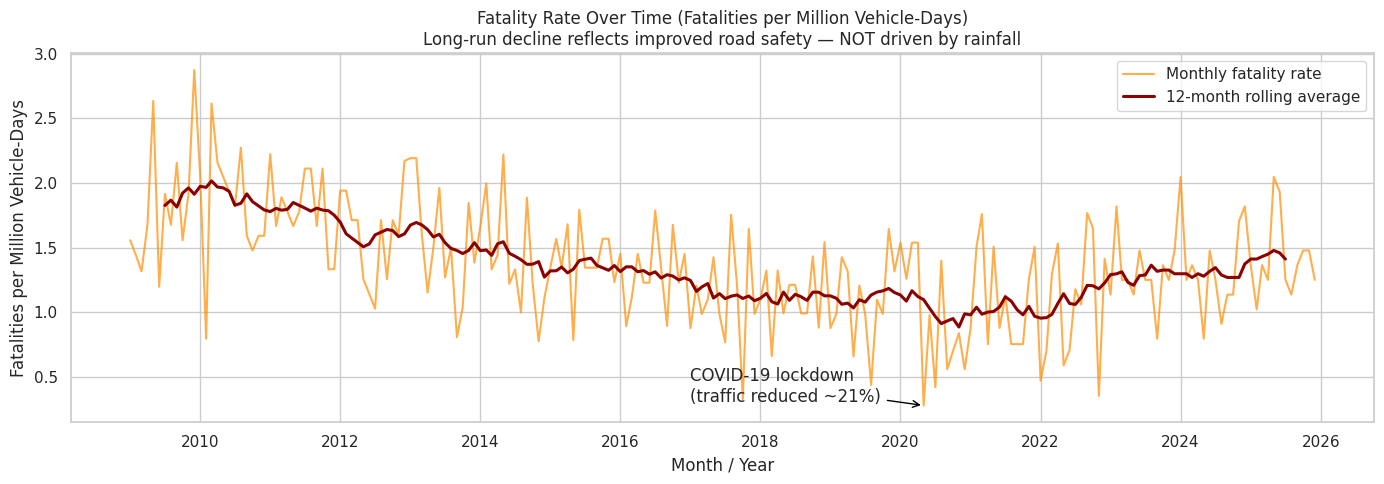

In [139]:
# Chart 2: Fatality Rate over Time — the long-run safety improvement story
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['fatality_rate'], color='darkorange', alpha=0.7, label='Monthly fatality rate')

# 12-month rolling average
rolling_avg = df['fatality_rate'].rolling(window=12, center=True).mean()
ax.plot(df.index, rolling_avg, color='darkred', linewidth=2.2, label='12-month rolling average')

# annotate COVID dip
covid_idx = df['fatality_rate'].idxmin()
ax.annotate('COVID-19 lockdown\n(traffic reduced ~21%)',
            xy=(covid_idx, df.loc[covid_idx, 'fatality_rate']),
            xytext=(pd.Timestamp('2017-01-01'), df['fatality_rate'].min() + 0.03),
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_title('Fatality Rate Over Time (Fatalities per Million Vehicle-Days)\nLong-run decline reflects improved road safety — NOT driven by rainfall')
ax.set_xlabel('Month / Year')
ax.set_ylabel('Fatalities per Million Vehicle-Days')
ax.legend()
plt.tight_layout()
plt.show()


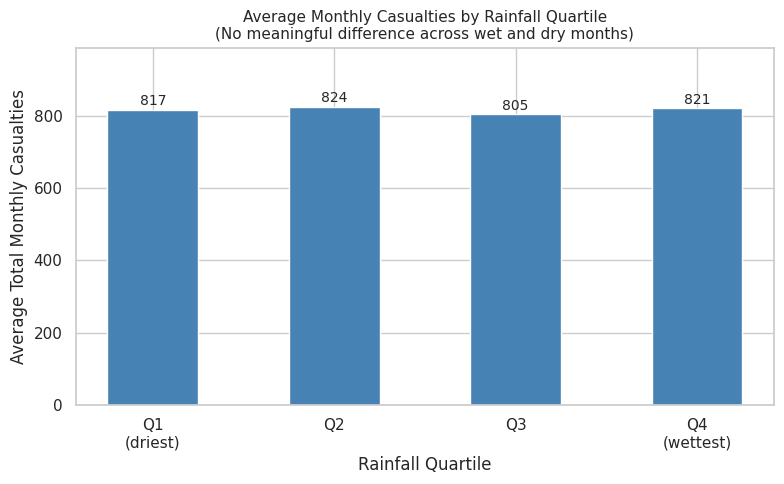

In [140]:
# Chart 3: Summary bar — average casualties by rainfall quartile
df['rainfall_quartile'] = pd.qcut(df['rainfall_mm'], q=4,
                                   labels=['Q1\n(driest)', 'Q2', 'Q3', 'Q4\n(wettest)'])
quartile_avg = df.groupby('rainfall_quartile', observed=True)['total_casualties'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quartile_avg.index, quartile_avg.values, color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars, quartile_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:.0f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, quartile_avg.max() * 1.2)
ax.set_title('Average Monthly Casualties by Rainfall Quartile\n(No meaningful difference across wet and dry months)', fontsize=11)
ax.set_xlabel('Rainfall Quartile')
ax.set_ylabel('Average Total Monthly Casualties')
plt.tight_layout()
plt.show()

### Narrative

**Summary of findings for traffic safety authorities and policymakers:**

Our analysis of 204 months of Singapore traffic and weather data (January 2009 – December 2025) produces a clear and actionable message:

**1. Rainfall alone is not a statistically significant driver of monthly traffic casualties in Singapore.** The Pearson correlation between monthly rainfall and total casualties is just 0.01, and our OLS regression confirms this: the rainfall coefficient (β = 0.07, p = 0.274) is far from statistical significance even after controlling for traffic volume. The bar chart above reinforces this — average casualties in the wettest months (Q4) are virtually the same as in the driest months (Q1).

**2. Traffic volume, by contrast, is a strong predictor** (β ≈ 0.005, p < 0.001), explaining the majority of the model's 41.6% explained variance. More vehicles on the road means more exposure and, in turn, more casualties — an intuitive result consistent with road-safety literature globally.

**3. The most encouraging finding is the long-run decline in fatality rate.** After normalising for traffic exposure, fatalities per million vehicle-days have fallen substantially over the 16-year window, likely reflecting cumulative improvements in vehicle safety technology, road engineering, and enforcement. This improvement is independent of rainfall.

**Caveat for policymakers:** This analysis uses monthly aggregates, which may mask event-level effects (e.g., a single intense rainstorm causing a spike in accidents on one afternoon). Daily or hourly incident data would be needed to detect such short-duration effects. The findings here should therefore be interpreted as evidence against a *sustained monthly-level* rainfall effect, not a blanket dismissal of weather as a road-safety factor.


# Possible Actions Based on Results (Act)

## Actions for Traffic Authorities and Policymakers

**1. Improve traffic-exposure data granularity.**  
The absence of publicly available *monthly* traffic flow data forced us to use annual figures, introducing measurement uncertainty. LTA should consider publishing monthly loop-detector or ERP data to enable more accurate exposure-normalised safety analyses in the future.


**2. Invest in event-level data collection.**  
The monthly aggregation may mask short-duration rainfall events that cause localised accident spikes. The Traffic Police and LTA should explore partnerships with MSS to match individual accident timestamps with hourly rainfall readings. This would enable a much finer-grained analysis and may reveal significant localised effects that our monthly study cannot detect.

**3. Continue and accelerate road-safety programmes.**  
The declining fatality rate over 2009–2025 suggests that existing safety measures (e.g., mandatory vehicle safety ratings, improved road markings, speed cameras) are working. Sustained investment in these programmes — rather than weather-specific responses — appears to be the most effective lever for further reducing fatalities.

**4. Focus traffic-volume management on high-exposure periods.**  
Traffic volume is the dominant predictor of casualties. Policies that reduce peak-hour vehicle exposure — such as congestion pricing (ERP), flexible work-from-home mandates, or improved public transport reliability — are likely to have a larger impact on monthly casualty counts than weather-related interventions.


# Final Reflection


## Considerations on Data Ethics

**Attribution and data provenance.**  
All datasets used in this project originate from official Singapore government portals (data.gov.sg) published by the Meteorological Service Singapore (MSS), Singapore Police Force (SPF), and Land Transport Authority (LTA). Proper attribution has been maintained throughout. Should this notebook be published or shared externally, the original data sources must be clearly cited and any licensing terms (e.g., Singapore Open Data Licence) respected.

**Representativeness and potential bias.**  
DS1 uses Changi as the sole rainfall reference station, which may not accurately represent rainfall in other parts of Singapore (e.g., the western or central regions). Conclusions drawn from this single-station measurement should not be over-generalised to represent island-wide conditions. Future work should incorporate multi-station data to reduce geographic bias.

**Misuse of findings.**  
The finding that monthly rainfall is not a significant predictor of casualties should be communicated carefully. A superficial reading could be used to argue against wet-weather road-safety measures entirely, which would be an overreach given the monthly aggregation limitations acknowledged in this study. Results should always be presented alongside their methodological constraints to avoid misinterpretation by non-technical audiences or media.

**Casualty proxy for accident frequency.**  
We use casualty counts as a proxy for accident frequency due to the absence of publicly available monthly incident counts. This introduces an ethical consideration: our analysis implicitly treats all casualties as equivalent, regardless of severity. A single multi-fatality accident could distort monthly counts in ways that do not reflect typical accident risk. Future studies should seek true incident-count data.


## Considerations on Data Privacy and Security

**No personal data involved.**  
All three datasets used in this analysis (DS1 rainfall totals, DS3 aggregate casualty counts, DS4 aggregate traffic volumes) are fully anonymised, population-level statistics published by official government agencies. No personally identifiable information — such as individual names, vehicle registration numbers, or accident-specific location coordinates — was used at any stage of the analysis. Consequently, there is no risk of individual re-identification, and no special data-handling or access-control measures are required.

**Storage and sharing.**  
The derived clean dataset (`sc3021_group9_clean_data.csv`) contains only aggregated monthly figures and carries no privacy risk. It may be shared openly alongside this notebook without restriction, provided the original data sources are attributed. If this work were extended to incorporate daily or event-level accident records that include location data at fine granularity, appropriate data governance controls (e.g., restricted access, data-sharing agreements with SPF) would need to be implemented.

**Security of the analytical environment.**  
The analysis was conducted in a Jupyter notebook environment. No API keys, credentials, or sensitive configuration files were embedded in the notebook. Any future work that interfaces with live APIs (e.g., the real-time MSS rainfall API) should store credentials in environment variables or a secrets manager, and never commit them to a version-control repository.

